# Inputs

In [18]:
from pathlib import Path
import pandas as pd

STUDY_CASE = "corridor"
SITE_ID_COLUMN = "Integrated Code"
CONTAMINATION_SCORE = "SumRel"
REFERENCE_CLOUD_SITE_COUNT = 15
DEGRADED_CLOUD_SITE_COUNT = 15

if STUDY_CASE == "DR":
    STUDY_CASE_LABEL = "Detroit River case study"
    CASE_ROOT_DIR = Path("../DetroitRiverCase")
    CLUSTER_LABELS = ("C1", "C2", "C3")
else:
    STUDY_CASE_LABEL = "Corridor case study"
    CASE_ROOT_DIR = Path("..")
    CLUSTER_LABELS = ("C1", "C2")

ARTIFACT_DIR = CASE_ROOT_DIR / "artifacts"
RESULTS_DIR = CASE_ROOT_DIR / "results"
FIGURE_DIR = CASE_ROOT_DIR / "figures"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def load_cluster_workbook(workbook_path: Path, cluster_labels: tuple[str, ...]) -> dict[str, pd.DataFrame]:
    workbook_sheets = pd.read_excel(workbook_path, sheet_name=None)
    cluster_tables = {
        sheet_name.removeprefix("cluster_"): sheet_table.reset_index(drop=True)
        for sheet_name, sheet_table in workbook_sheets.items()
        if sheet_name.startswith("cluster_")
    }
    missing_sheets = [
        f"cluster_{cluster_label}"
        for cluster_label in cluster_labels
        if cluster_label not in cluster_tables
    ]
    if missing_sheets:
        raise ValueError(f"Missing required sheets in {workbook_path.name}: {missing_sheets}")
    return {cluster_label: cluster_tables[cluster_label] for cluster_label in cluster_labels}


stressor_matrix_workbook_path = ARTIFACT_DIR / "A6_poles_assigned_stressor_matrix.xlsx"
bray_curtis_workbook_path = ARTIFACT_DIR / "A7_bray_curtis_dissimilarity_matrix.xlsx"
nmds_configuration_workbook_path = ARTIFACT_DIR / "A8_NMDS_Euc_configuration.xlsx"

cluster_stressor_tables = load_cluster_workbook(stressor_matrix_workbook_path, CLUSTER_LABELS)
cluster_bray_curtis_tables = load_cluster_workbook(bray_curtis_workbook_path, CLUSTER_LABELS)
cluster_nmds_coordinate_tables = load_cluster_workbook(nmds_configuration_workbook_path, CLUSTER_LABELS)

C1_S_c = cluster_stressor_tables["C1"]
C2_S_c = cluster_stressor_tables["C2"]
C1_bray_curtis_dissimilarity = cluster_bray_curtis_tables["C1"]
C2_bray_curtis_dissimilarity = cluster_bray_curtis_tables["C2"]
C1_NMDS_euc_coordinates = cluster_nmds_coordinate_tables["C1"]
C2_NMDS_euc_coordinates = cluster_nmds_coordinate_tables["C2"]
if STUDY_CASE == "DR":
    C3_S_c = cluster_stressor_tables["C3"]
    C3_bray_curtis_dissimilarity = cluster_bray_curtis_tables["C3"]
    C3_NMDS_euc_coordinates = cluster_nmds_coordinate_tables["C3"]

print(f"Study case: {STUDY_CASE_LABEL}")
print(f"Loaded stressor-score workbook: {stressor_matrix_workbook_path}")
print(f"Loaded Bray-Curtis workbook: {bray_curtis_workbook_path}")
print(f"Loaded NMDS configuration workbook: {nmds_configuration_workbook_path}")
for cluster_label in CLUSTER_LABELS:
    stressor_table = cluster_stressor_tables[cluster_label]
    bray_curtis_table = cluster_bray_curtis_tables[cluster_label]
    coordinate_table = cluster_nmds_coordinate_tables[cluster_label]
    print(f"{cluster_label} stressor scores matrix with poles: {stressor_table.shape[0]} rows x {stressor_table.shape[1]} columns")
    display(stressor_table.head())
    print(f"{cluster_label} Bray-Curtis dissimilarity matrix: {bray_curtis_table.shape[0]} rows x {bray_curtis_table.shape[1] - 1} dissimilarity columns")
    display(bray_curtis_table.head())
    print(f"{cluster_label} NMDS-derived Euclidean coordinates: {coordinate_table.shape[0]} rows x {coordinate_table.shape[1]} columns")
    display(coordinate_table.head())

Study case: Corridor case study
Loaded stressor-score workbook: ../artifacts/A6_poles_assigned_stressor_matrix.xlsx
Loaded Bray-Curtis workbook: ../artifacts/A7_bray_curtis_dissimilarity_matrix.xlsx
Loaded NMDS configuration workbook: ../artifacts/A8_NMDS_Euc_configuration.xlsx
C1 stressor scores matrix with poles: 176 rows x 8 columns


,Integrated Code,PC1,PC2,PC3,PC4,PC5,SumRel,MaxRel
0,DR-02,-3.551586,-0.467324,2.058308,-0.704420,0.548320,-2.116702,2.058308
1,DR-03,-8.981867,-2.461472,-3.700149,-1.637132,0.917744,-15.862876,0.917744
2,DR-04,-8.113969,-2.255861,0.336496,-1.320521,0.431065,-10.922790,0.431065
3,DR-07,-6.193281,-1.455419,1.262757,-1.159607,0.972588,-6.572962,1.262757
4,DR-08,-3.585232,-2.408755,0.883794,0.448607,1.023400,-3.638186,1.023400


C1 Bray-Curtis dissimilarity matrix: 176 rows x 176 dissimilarity columns


,Integrated Code,DR-02,DR-03,DR-04,DR-07,DR-08,DR-09,DR-21,DR-32,DR-76,...,DR-152,DR-154,DR-156,DR-157,DR-158,DR-159,LSC-64,LSC-65,C1 ref pole,C1 deg pole
0,DR-02,0.000000,0.928049,0.931827,0.118827,0.940263,0.277829,0.935484,0.879540,0.933094,...,0.876660,0.935484,0.935484,0.930329,0.944440,0.935484,0.950988,0.933094,0.800759,0.932133
1,DR-03,0.928049,0.000000,0.497359,0.931113,0.115242,0.920167,0.150590,0.142174,0.143795,...,0.819812,0.502773,0.376910,0.712969,0.753250,0.786555,0.374123,0.329696,0.453914,0.761671
2,DR-04,0.931827,0.497359,0.000000,0.936349,0.530942,0.926334,0.480822,0.449006,0.439002,...,0.819727,0.298833,0.360372,0.567879,0.525390,0.644170,0.679251,0.378669,0.390817,0.614436
3,DR-07,0.118827,0.931113,0.936349,0.000000,0.942272,0.305017,0.940410,0.884466,0.939479,...,0.879724,0.940410,0.940410,0.935255,0.974415,0.940668,0.935707,0.939479,0.805281,0.938235
4,DR-08,0.940263,0.115242,0.530942,0.942272,0.000000,0.927602,0.098398,0.146752,0.244681,...,0.867860,0.527018,0.408213,0.710444,0.784552,0.750805,0.391469,0.327625,0.445343,0.715705


C1 NMDS-derived Euclidean coordinates: 176 rows x 4 columns


...

,Integrated Code,PC1,PC2,PC3,PC4,PC5,SumRel,MaxRel
0,DR-06,7.386599,3.868513,4.100456,0.649814,2.058903,18.064286,7.386599
1,DR-09,-3.933513,0.606304,-1.559935,-0.752677,0.909750,-4.730071,0.909750
2,DR-10,-4.027689,-1.652612,-3.305305,-0.294055,0.733454,-8.546208,0.733454
3,DR-43,0.794700,-1.366539,1.454469,-0.436560,0.806396,1.252467,1.454469
4,DR-54,10.348878,-0.687643,0.820847,-1.050374,0.085418,9.517125,10.348878


C2 Bray-Curtis dissimilarity matrix: 163 rows x 163 dissimilarity columns


,Integrated Code,DR-06,DR-09,DR-10,DR-43,DR-54,DR-65,DR-76,DR-87,DR-98,...,DR-146,DR-149,DR-150,DR-151,DR-155,LSC-65,LSC-66,LSC-67,C2 ref pole,C2 deg pole
0,DR-06,0.000000,0.460811,0.943085,0.619201,0.659804,0.930426,0.933091,0.158124,0.924736,...,0.761794,0.508480,0.933184,0.811755,0.820654,0.932853,0.934194,0.933091,0.625080,0.935884
1,DR-09,0.460811,0.000000,0.927602,0.451357,0.624030,0.927602,0.927602,0.345980,0.904728,...,0.365516,0.424208,0.922226,0.819005,0.790547,0.932127,0.918552,0.932127,0.556255,0.962425
2,DR-10,0.943085,0.927602,0.000000,0.580711,0.646645,0.309935,0.186976,0.970414,0.226022,...,0.852632,0.859557,0.710471,0.728461,0.746258,0.332164,0.397775,0.647137,0.603068,0.871830
3,DR-43,0.619201,0.451357,0.580711,0.000000,0.243132,0.480769,0.638093,0.512574,0.472565,...,0.522571,0.413462,0.600628,0.486991,0.513786,0.510945,0.623215,0.547195,0.264516,0.758224
4,DR-54,0.659804,0.624030,0.646645,0.243132,0.000000,0.380199,0.704027,0.660926,0.538499,...,0.544549,0.453297,0.446782,0.377101,0.359940,0.392857,0.645193,0.402195,0.334243,0.522984


C2 NMDS-derived Euclidean coordinates: 163 rows x 4 columns


,Integrated Code,NMDS Axis 1,NMDS Axis 2,NMDS Axis 3
0,DR-06,-0.456113,-0.091818,0.117300
1,DR-09,-0.460362,0.023999,-0.124944
2,DR-10,0.067005,0.422015,0.090003
3,DR-43,-0.156437,0.124416,0.012159
4,DR-54,-0.047474,0.054263,-0.008409


# Definition Corner

Define the reference-cloud ZCI, NMDS fidelity, diagnostic classification, and plotting helpers used below. The main ZCI is now based on relative proximity to a trimmed reference cloud and the degraded pole; the original reference-to-degraded axis projection is retained as an interpretive diagnostic rather than the only condition score.

In [19]:
import matplotlib.pyplot as plt
import numpy as np

REFERENCE_TRIM_DEGRADED_LIKE_RATIO = 1.0
MIN_REFERENCE_CLOUD_SIZE = 3
REFERENCE_CLOUD_DISTANCE_METHOD = "median"
REFERENCE_CLOUD_TRIM_FRACTION = 0.2
FIDELITY_RESIDUAL_QUANTILE_THRESHOLD = 0.75
PROJECTION_RESIDUAL_QUANTILE_THRESHOLD = 0.75


def get_nmds_axis_columns(configuration_table: pd.DataFrame) -> list[str]:
    axis_columns = [
        column
        for column in configuration_table.columns
        if str(column).startswith("NMDS Axis")
    ]
    if not axis_columns:
        raise ValueError("The NMDS configuration table must contain at least one NMDS axis column.")
    return axis_columns


def coordinate_table_from_configuration(
    configuration_table: pd.DataFrame,
    id_col: str = SITE_ID_COLUMN,
) -> pd.DataFrame:
    if id_col not in configuration_table.columns:
        raise KeyError(f"The NMDS configuration table must contain the identifier column {id_col!r}.")
    axis_columns = get_nmds_axis_columns(configuration_table)
    coordinate_table = configuration_table[[id_col, *axis_columns]].copy()
    coordinate_table[id_col] = coordinate_table[id_col].astype(str)
    if coordinate_table[id_col].duplicated().any():
        duplicated_ids = coordinate_table.loc[coordinate_table[id_col].duplicated(), id_col].unique().tolist()[:5]
        raise ValueError(f"Duplicate coordinate labels found: {duplicated_ids}")
    coordinate_table = coordinate_table.set_index(id_col).apply(pd.to_numeric, errors="coerce")
    if coordinate_table.isna().any().any():
        incomplete_columns = coordinate_table.columns[coordinate_table.isna().any()].tolist()
        raise ValueError(f"Coordinate table contains missing or non-numeric values in: {incomplete_columns}")
    return coordinate_table


def coerce_symmetric_dissimilarity_matrix(
    raw_table: pd.DataFrame,
    id_col: str = SITE_ID_COLUMN,
) -> pd.DataFrame:
    if id_col not in raw_table.columns:
        raise KeyError(f"The raw dissimilarity table must contain the identifier column {id_col!r}.")
    matrix = raw_table.copy()
    matrix[id_col] = matrix[id_col].astype(str)
    if matrix[id_col].duplicated().any():
        duplicated_ids = matrix.loc[matrix[id_col].duplicated(), id_col].unique().tolist()[:5]
        raise ValueError(f"Duplicate row labels found in the dissimilarity table: {duplicated_ids}")
    matrix = matrix.set_index(id_col)
    matrix.columns = matrix.columns.astype(str)
    missing_columns = [label for label in matrix.index if label not in matrix.columns]
    if missing_columns:
        raise ValueError(f"Matrix columns are missing row labels: {missing_columns[:10]}")
    matrix = matrix.loc[matrix.index, matrix.index].apply(pd.to_numeric, errors="coerce")
    if matrix.isna().any().any():
        incomplete_columns = matrix.columns[matrix.isna().any()].tolist()
        raise ValueError(f"Dissimilarity matrix contains missing or non-numeric values in: {incomplete_columns[:10]}")
    matrix_values = matrix.to_numpy(dtype=float)
    symmetric_values = 0.5 * (matrix_values + matrix_values.T)
    np.fill_diagonal(symmetric_values, 0.0)
    symmetric_matrix = pd.DataFrame(symmetric_values, index=matrix.index.astype(str), columns=matrix.index.astype(str))
    symmetric_matrix.index.name = id_col
    symmetric_matrix.columns.name = id_col
    return symmetric_matrix


def extract_upper_triangle_pairs(dissimilarity_matrix: pd.DataFrame) -> pd.DataFrame:
    labels = dissimilarity_matrix.index.astype(str).to_numpy()
    row_index, column_index = np.triu_indices(len(labels), k=1)
    return pd.DataFrame(
        {
            "label_i": labels[row_index],
            "label_j": labels[column_index],
            "original_dissimilarity": dissimilarity_matrix.to_numpy(dtype=float)[row_index, column_index],
        }
    )


def build_euclidean_distance_matrix(coordinate_table: pd.DataFrame) -> pd.DataFrame:
    coordinate_values = coordinate_table.to_numpy(dtype=float)
    differences = coordinate_values[:, None, :] - coordinate_values[None, :, :]
    distance_values = np.sqrt(np.sum(differences ** 2, axis=2))
    return pd.DataFrame(distance_values, index=coordinate_table.index.astype(str), columns=coordinate_table.index.astype(str))


def pool_adjacent_violators(values, weights=None) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    if weights is None:
        weights = np.ones(values.shape[0], dtype=float)
    else:
        weights = np.asarray(weights, dtype=float)
    if values.shape != weights.shape:
        raise ValueError("values and weights must have the same shape.")
    if (weights <= 0.0).any():
        raise ValueError("weights must all be positive.")

    block_values: list[float] = []
    block_weights: list[float] = []
    block_lengths: list[int] = []
    for value, weight in zip(values, weights):
        block_values.append(float(value))
        block_weights.append(float(weight))
        block_lengths.append(1)
        while len(block_values) >= 2 and block_values[-2] > block_values[-1]:
            merged_weight = block_weights[-2] + block_weights[-1]
            merged_value = (block_values[-2] * block_weights[-2] + block_values[-1] * block_weights[-1]) / merged_weight
            merged_length = block_lengths[-2] + block_lengths[-1]
            block_values[-2:] = [merged_value]
            block_weights[-2:] = [merged_weight]
            block_lengths[-2:] = [merged_length]
    return np.repeat(np.asarray(block_values, dtype=float), block_lengths)


def fit_isotonic_disparities(current_distances, rank_positions) -> np.ndarray:
    current_distances = np.asarray(current_distances, dtype=float)
    rank_positions = np.asarray(rank_positions, dtype=float)
    if current_distances.shape != rank_positions.shape:
        raise ValueError("current_distances and rank_positions must have the same shape.")
    order = np.argsort(rank_positions, kind="mergesort")
    sorted_ranks = rank_positions[order]
    sorted_distances = current_distances[order]
    _, inverse = np.unique(sorted_ranks, return_inverse=True)
    group_counts = np.bincount(inverse).astype(float)
    group_means = np.bincount(inverse, weights=sorted_distances) / group_counts
    group_fits = pool_adjacent_violators(group_means, group_counts)
    fitted_sorted = group_fits[inverse]
    fitted_norm = np.linalg.norm(fitted_sorted)
    distance_norm = np.linalg.norm(sorted_distances)
    if fitted_norm > 0.0 and distance_norm > 0.0:
        fitted_sorted = fitted_sorted * (distance_norm / fitted_norm)
    fitted_disparities = np.empty_like(fitted_sorted)
    fitted_disparities[order] = fitted_sorted
    return fitted_disparities


def build_site_nmds_fidelity_table(
    bray_curtis_table: pd.DataFrame,
    configuration_table: pd.DataFrame,
    cluster_label: str,
    id_col: str = SITE_ID_COLUMN,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    dissimilarity_matrix = coerce_symmetric_dissimilarity_matrix(bray_curtis_table, id_col=id_col)
    coordinate_table = coordinate_table_from_configuration(configuration_table, id_col=id_col)
    common_labels = [label for label in coordinate_table.index.astype(str) if label in dissimilarity_matrix.index]
    if len(common_labels) < 3:
        raise ValueError(f"{cluster_label} needs at least three shared labels for NMDS fidelity diagnostics.")
    coordinate_table = coordinate_table.loc[common_labels]
    dissimilarity_matrix = dissimilarity_matrix.loc[common_labels, common_labels]

    original_pairs = extract_upper_triangle_pairs(dissimilarity_matrix)
    euclidean_pairs = extract_upper_triangle_pairs(build_euclidean_distance_matrix(coordinate_table))
    pair_table = original_pairs.copy()
    pair_table["euclidean_distance"] = euclidean_pairs["original_dissimilarity"].to_numpy(dtype=float)
    pair_table["rank"] = pd.Series(pair_table["original_dissimilarity"]).rank(method="average").to_numpy(dtype=float)
    pair_table["disparity"] = fit_isotonic_disparities(
        pair_table["euclidean_distance"].to_numpy(dtype=float),
        pair_table["rank"].to_numpy(dtype=float),
    )
    pair_table["shepard_residual"] = pair_table["euclidean_distance"] - pair_table["disparity"]
    pair_table["abs_shepard_residual"] = pair_table["shepard_residual"].abs()

    ref_pole_label = f"{cluster_label} ref pole"
    deg_pole_label = f"{cluster_label} deg pole"
    real_site_labels = [label for label in coordinate_table.index.astype(str) if label not in {ref_pole_label, deg_pole_label}]
    site_records: list[dict[str, object]] = []
    for site_id in real_site_labels:
        site_pair_mask = (pair_table["label_i"] == site_id) | (pair_table["label_j"] == site_id)
        site_pairs = pair_table.loc[site_pair_mask]
        ref_pair = site_pairs.loc[(site_pairs["label_i"] == ref_pole_label) | (site_pairs["label_j"] == ref_pole_label)]
        deg_pair = site_pairs.loc[(site_pairs["label_i"] == deg_pole_label) | (site_pairs["label_j"] == deg_pole_label)]
        site_records.append(
            {
                id_col: site_id,
                "NMDS pair count": int(site_pairs.shape[0]),
                "mean abs Shepard residual": float(site_pairs["abs_shepard_residual"].mean()),
                "median abs Shepard residual": float(site_pairs["abs_shepard_residual"].median()),
                "p90 abs Shepard residual": float(site_pairs["abs_shepard_residual"].quantile(0.90)),
                "max abs Shepard residual": float(site_pairs["abs_shepard_residual"].max()),
                "ref-pair abs Shepard residual": float(ref_pair["abs_shepard_residual"].iloc[0]) if not ref_pair.empty else np.nan,
                "deg-pair abs Shepard residual": float(deg_pair["abs_shepard_residual"].iloc[0]) if not deg_pair.empty else np.nan,
            }
        )
    return pd.DataFrame(site_records), pair_table


def select_endpoint_candidates(
    stressor_table: pd.DataFrame,
    endpoint_count: int,
    score_col: str = CONTAMINATION_SCORE,
    id_col: str = SITE_ID_COLUMN,
) -> dict[str, list[str]]:
    required_columns = {id_col, score_col}
    missing_columns = required_columns.difference(stressor_table.columns)
    if missing_columns:
        raise KeyError(f"The stressor table is missing required columns: {sorted(missing_columns)}")
    real_site_table = stressor_table[[id_col, score_col]].copy()
    real_site_table[id_col] = real_site_table[id_col].astype(str)
    real_site_table = real_site_table.loc[~real_site_table[id_col].str.endswith(" pole")].copy()
    real_site_table[score_col] = pd.to_numeric(real_site_table[score_col], errors="coerce")
    if real_site_table[score_col].isna().any():
        incomplete_ids = real_site_table.loc[real_site_table[score_col].isna(), id_col].tolist()[:10]
        raise ValueError(f"The contamination score column contains missing or non-numeric values for: {incomplete_ids}")
    if real_site_table.shape[0] < 2 * endpoint_count:
        raise ValueError("endpoint_count is too large to select non-overlapping reference and degraded candidates.")
    ranked_table = real_site_table.sort_values([score_col, id_col], ascending=[True, True], kind="mergesort")
    return {
        "reference candidates": ranked_table.head(endpoint_count)[id_col].tolist(),
        "degraded candidates": ranked_table.tail(endpoint_count)[id_col].tolist(),
    }


def trim_reference_cloud_candidates(
    coordinate_table: pd.DataFrame,
    reference_candidate_ids: list[str],
    degraded_pole_label: str,
    trim_ratio: float = REFERENCE_TRIM_DEGRADED_LIKE_RATIO,
    min_reference_cloud_size: int = MIN_REFERENCE_CLOUD_SIZE,
) -> tuple[list[str], pd.DataFrame]:
    reference_candidate_ids = [str(site_id) for site_id in reference_candidate_ids]
    missing_reference_ids = [site_id for site_id in reference_candidate_ids if site_id not in coordinate_table.index]
    if missing_reference_ids:
        raise KeyError(f"Reference candidates missing from the NMDS configuration: {missing_reference_ids[:10]}")
    if degraded_pole_label not in coordinate_table.index:
        raise KeyError(f"Degraded pole {degraded_pole_label!r} missing from the NMDS configuration.")
    if len(reference_candidate_ids) < min_reference_cloud_size:
        raise ValueError("Not enough reference candidates to build a reference cloud.")

    retained_ids = list(reference_candidate_ids)
    degraded_coordinates = coordinate_table.loc[degraded_pole_label].to_numpy(dtype=float)
    for _ in range(20):
        reference_center = coordinate_table.loc[retained_ids].mean(axis=0).to_numpy(dtype=float)
        candidate_values = coordinate_table.loc[retained_ids].to_numpy(dtype=float)
        distance_to_reference_center = np.linalg.norm(candidate_values - reference_center, axis=1)
        distance_to_degraded_pole = np.linalg.norm(candidate_values - degraded_coordinates, axis=1)
        degraded_like_mask = distance_to_degraded_pole < trim_ratio * distance_to_reference_center
        proposed_retained = [site_id for site_id, degraded_like in zip(retained_ids, degraded_like_mask) if not degraded_like]
        if len(proposed_retained) < min_reference_cloud_size:
            consistency_margin = distance_to_degraded_pole - trim_ratio * distance_to_reference_center
            keep_order = np.argsort(consistency_margin)[::-1][:min_reference_cloud_size]
            proposed_retained = [retained_ids[index] for index in sorted(keep_order)]
        if proposed_retained == retained_ids:
            break
        retained_ids = proposed_retained

    final_reference_center = coordinate_table.loc[retained_ids].mean(axis=0).to_numpy(dtype=float)
    diagnostic_records: list[dict[str, object]] = []
    for site_id in reference_candidate_ids:
        site_coordinates = coordinate_table.loc[site_id].to_numpy(dtype=float)
        distance_to_reference_center = float(np.linalg.norm(site_coordinates - final_reference_center))
        distance_to_degraded_pole = float(np.linalg.norm(site_coordinates - degraded_coordinates))
        diagnostic_records.append(
            {
                SITE_ID_COLUMN: site_id,
                "reference cloud status": "retained" if site_id in retained_ids else "trimmed",
                "distance to retained reference center": distance_to_reference_center,
                "distance to degraded pole": distance_to_degraded_pole,
                "degraded/reference distance ratio": distance_to_degraded_pole / distance_to_reference_center if distance_to_reference_center > 0.0 else np.inf,
                "trim rule": f"trim if distance_to_degraded_pole < {trim_ratio} * distance_to_reference_center",
            }
        )
    return retained_ids, pd.DataFrame(diagnostic_records)


def distance_to_reference_cloud(
    point_coordinates: np.ndarray,
    reference_cloud_coordinates: np.ndarray,
    method: str = REFERENCE_CLOUD_DISTANCE_METHOD,
    trim_fraction: float = REFERENCE_CLOUD_TRIM_FRACTION,
) -> float:
    distances = np.linalg.norm(reference_cloud_coordinates - point_coordinates, axis=1)
    if method == "median":
        return float(np.median(distances))
    if method == "mean":
        return float(np.mean(distances))
    if method == "trimmed_mean":
        sorted_distances = np.sort(distances)
        trim_count = int(np.floor(trim_fraction * sorted_distances.shape[0]))
        if trim_count > 0 and 2 * trim_count < sorted_distances.shape[0]:
            sorted_distances = sorted_distances[trim_count:-trim_count]
        return float(np.mean(sorted_distances))
    raise ValueError("method must be one of 'median', 'mean', or 'trimmed_mean'.")


def build_reference_cloud_zci_table(
    configuration_table: pd.DataFrame,
    stressor_table: pd.DataFrame,
    bray_curtis_table: pd.DataFrame,
    cluster_label: str,
    reference_endpoint_count: int = REFERENCE_CLOUD_SITE_COUNT,
    id_col: str = SITE_ID_COLUMN,
    score_col: str = CONTAMINATION_SCORE,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    coordinate_table = coordinate_table_from_configuration(configuration_table, id_col=id_col)
    ref_pole_label = f"{cluster_label} ref pole"
    deg_pole_label = f"{cluster_label} deg pole"
    if deg_pole_label not in coordinate_table.index:
        raise KeyError(f"Degraded pole {deg_pole_label!r} was not found in the {cluster_label} coordinates.")

    endpoint_candidates = select_endpoint_candidates(
        stressor_table,
        endpoint_count=reference_endpoint_count,
        score_col=score_col,
        id_col=id_col,
    )
    retained_reference_ids, reference_cloud_diagnostic = trim_reference_cloud_candidates(
        coordinate_table,
        endpoint_candidates["reference candidates"],
        degraded_pole_label=deg_pole_label,
    )
    retained_reference_coordinates = coordinate_table.loc[retained_reference_ids].to_numpy(dtype=float)
    reference_center = coordinate_table.loc[retained_reference_ids].mean(axis=0).to_numpy(dtype=float)
    degraded_coordinates = coordinate_table.loc[deg_pole_label].to_numpy(dtype=float)
    gradient_axis = degraded_coordinates - reference_center
    gradient_axis_length_squared = float(np.dot(gradient_axis, gradient_axis))
    if gradient_axis_length_squared <= 0.0:
        raise ValueError(f"The retained reference cloud center and degraded pole overlap for {cluster_label}.")

    real_site_coordinates = coordinate_table.drop(index=[label for label in (ref_pole_label, deg_pole_label) if label in coordinate_table.index])
    score_lookup = stressor_table[[id_col, score_col]].copy()
    score_lookup[id_col] = score_lookup[id_col].astype(str)
    score_lookup = score_lookup.loc[~score_lookup[id_col].str.endswith(" pole")].copy()
    score_lookup[score_col] = pd.to_numeric(score_lookup[score_col], errors="coerce")

    zci_records: list[dict[str, object]] = []
    for site_id, site_row in real_site_coordinates.iterrows():
        site_coordinates = site_row.to_numpy(dtype=float)
        distance_to_degraded_pole = float(np.linalg.norm(site_coordinates - degraded_coordinates))
        distance_to_ref_cloud = distance_to_reference_cloud(site_coordinates, retained_reference_coordinates)
        denominator = distance_to_degraded_pole + distance_to_ref_cloud
        reference_cloud_zci = distance_to_degraded_pole / denominator if denominator > 0.0 else np.nan

        displacement_from_reference_center = site_coordinates - reference_center
        projection_fraction = float(np.dot(displacement_from_reference_center, gradient_axis) / gradient_axis_length_squared)
        projected_component = projection_fraction * gradient_axis
        projection_residual = float(np.linalg.norm(displacement_from_reference_center - projected_component))
        parallel_component_length_squared = float(np.dot(projected_component, projected_component))
        residual_component_length_squared = projection_residual ** 2
        axis_explained_fraction = (
            parallel_component_length_squared / (parallel_component_length_squared + residual_component_length_squared)
            if parallel_component_length_squared + residual_component_length_squared > 0.0
            else np.nan
        )
        zci_records.append(
            {
                id_col: str(site_id),
                "ZCI": reference_cloud_zci,
                "ZCI axis projection": 1.0 - projection_fraction,
                "distance to reference cloud": distance_to_ref_cloud,
                "distance to degraded pole": distance_to_degraded_pole,
                "projection residual": projection_residual,
                "axis explained fraction": axis_explained_fraction,
                "reference cloud size": len(retained_reference_ids),
            }
        )
    zci_table = pd.DataFrame(zci_records).merge(score_lookup, on=id_col, how="left", validate="one_to_one")

    site_fidelity_table, shepard_pair_table = build_site_nmds_fidelity_table(
        bray_curtis_table,
        configuration_table,
        cluster_label=cluster_label,
        id_col=id_col,
    )
    zci_table = zci_table.merge(site_fidelity_table, on=id_col, how="left", validate="one_to_one")

    projection_residual_threshold = float(zci_table["projection residual"].quantile(PROJECTION_RESIDUAL_QUANTILE_THRESHOLD))
    fidelity_residual_threshold = float(zci_table["mean abs Shepard residual"].quantile(FIDELITY_RESIDUAL_QUANTILE_THRESHOLD))
    zci_table["axis alignment class"] = np.where(
        zci_table["projection residual"] <= projection_residual_threshold,
        "axis-aligned",
        "off-axis",
    )
    zci_table["NMDS fidelity class"] = np.where(
        zci_table["mean abs Shepard residual"] <= fidelity_residual_threshold,
        "high NMDS fidelity",
        "low NMDS fidelity",
    )
    zci_table["ZCI 2x2 diagnostic"] = [
        _classify_zci_diagnostic(axis_class, fidelity_class)
        for axis_class, fidelity_class in zip(zci_table["axis alignment class"], zci_table["NMDS fidelity class"])
    ]
    zci_table["projection residual threshold"] = projection_residual_threshold
    zci_table["NMDS fidelity residual threshold"] = fidelity_residual_threshold
    zci_table.insert(0, "Community Type", cluster_label)
    reference_cloud_diagnostic.insert(0, "Community Type", cluster_label)
    shepard_pair_table.insert(0, "Community Type", cluster_label)
    return zci_table, reference_cloud_diagnostic, shepard_pair_table


def _classify_zci_diagnostic(axis_class: str, fidelity_class: str) -> str:
    if axis_class == "axis-aligned" and fidelity_class == "high NMDS fidelity":
        return "strong ZCI support"
    if axis_class == "off-axis" and fidelity_class == "high NMDS fidelity":
        return "off-axis composition"
    if axis_class == "axis-aligned" and fidelity_class == "low NMDS fidelity":
        return "axis-aligned but low NMDS fidelity"
    return "low ZCI support"


def build_zci_stressor_table(
    zci_table: pd.DataFrame,
    score_col: str = CONTAMINATION_SCORE,
    id_col: str = SITE_ID_COLUMN,
) -> pd.DataFrame:
    required_columns = {id_col, score_col, "ZCI", "projection residual", "mean abs Shepard residual"}
    missing_columns = required_columns.difference(zci_table.columns)
    if missing_columns:
        raise KeyError(f"The ZCI table is missing required columns: {sorted(missing_columns)}")
    return zci_table[[id_col, score_col, "ZCI", "projection residual", "mean abs Shepard residual", "ZCI 2x2 diagnostic"]].copy()


def render_zci_vs_residual_figure(
    zci_table: pd.DataFrame,
    cluster_label: str,
    dpi: int = 300,
) -> tuple[plt.Figure, plt.Axes]:
    figure, axis = plt.subplots(figsize=(7.2, 5.2), dpi=dpi)
    axis.scatter(
        zci_table["ZCI"],
        zci_table["projection residual"],
        s=34,
        color="#1f78b4",
        alpha=0.78,
        edgecolor="white",
        linewidth=0.35,
    )
    axis.axvline(1.0, color="#2ca25f", linestyle="--", linewidth=1.2, label="reference-like")
    axis.axvline(0.0, color="#de2d26", linestyle="--", linewidth=1.2, label="degraded pole")
    axis.axhline(
        float(zci_table["projection residual threshold"].iloc[0]),
        color="#636363",
        linestyle=":",
        linewidth=1.1,
        label="off-axis threshold",
    )
    axis.set_xlabel("Reference-cloud ZCI", fontsize=12, fontweight="bold")
    axis.set_ylabel("Projection residual", fontsize=12, fontweight="bold")
    axis.set_title(f"{cluster_label} ZCI vs Projection Residual", fontsize=14, fontweight="bold")
    axis.grid(True, linestyle="--", linewidth=0.8, alpha=0.35)
    axis.set_axisbelow(True)
    axis.legend(frameon=False)
    figure.tight_layout()
    return figure, axis


def render_zci_2x2_diagnostic_figure(
    zci_table: pd.DataFrame,
    cluster_label: str,
    dpi: int = 300,
) -> tuple[plt.Figure, plt.Axes]:
    palette = {
        "strong ZCI support": "#2ca25f",
        "off-axis composition": "#fdae6b",
        "axis-aligned but low NMDS fidelity": "#6baed6",
        "low ZCI support": "#de2d26",
    }
    figure, axis = plt.subplots(figsize=(7.2, 5.2), dpi=dpi)
    for diagnostic_class, subset in zci_table.groupby("ZCI 2x2 diagnostic", sort=False):
        axis.scatter(
            subset["projection residual"],
            subset["mean abs Shepard residual"],
            s=38,
            color=palette.get(diagnostic_class, "#737373"),
            alpha=0.82,
            edgecolor="white",
            linewidth=0.35,
            label=diagnostic_class,
        )
    axis.axvline(float(zci_table["projection residual threshold"].iloc[0]), color="#525252", linestyle="--", linewidth=1.1)
    axis.axhline(float(zci_table["NMDS fidelity residual threshold"].iloc[0]), color="#525252", linestyle="--", linewidth=1.1)
    axis.set_xlabel("Projection residual", fontsize=12, fontweight="bold")
    axis.set_ylabel("Mean absolute Shepard residual", fontsize=12, fontweight="bold")
    axis.set_title(f"{cluster_label} ZCI 2x2 Diagnostic", fontsize=14, fontweight="bold")
    axis.grid(True, linestyle="--", linewidth=0.8, alpha=0.35)
    axis.set_axisbelow(True)
    axis.legend(frameon=False, fontsize=8)
    figure.tight_layout()
    return figure, axis


def _fit_simple_ols_line(
    x_values: pd.Series,
    y_values: pd.Series,
) -> tuple[float, float, float]:
    x_array = pd.to_numeric(x_values, errors="coerce").to_numpy(dtype=float)
    y_array = pd.to_numeric(y_values, errors="coerce").to_numpy(dtype=float)
    valid_mask = np.isfinite(x_array) & np.isfinite(y_array)
    x_array = x_array[valid_mask]
    y_array = y_array[valid_mask]
    if x_array.size < 3:
        raise ValueError("At least three paired observations are required to compute adjusted R-squared.")
    if np.isclose(np.var(x_array), 0.0):
        raise ValueError("The contamination score values must vary to fit an OLS regression.")
    slope, intercept = np.polyfit(x_array, y_array, deg=1)
    predicted_values = intercept + slope * x_array
    residual_sum_squares = float(np.sum((y_array - predicted_values) ** 2))
    total_sum_squares = float(np.sum((y_array - np.mean(y_array)) ** 2))
    r_squared = 1.0 - residual_sum_squares / total_sum_squares if total_sum_squares > 0.0 else 0.0
    adjusted_r_squared = 1.0 - (1.0 - r_squared) * (x_array.size - 1) / (x_array.size - 2)
    return float(slope), float(intercept), float(adjusted_r_squared)


def render_zci_vs_contamination_figure(
    zci_stressor_table: pd.DataFrame,
    cluster_label: str,
    score_col: str = CONTAMINATION_SCORE,
    dpi: int = 300,
) -> tuple[plt.Figure, plt.Axes]:
    figure, axis = plt.subplots(figsize=(7.2, 5.2), dpi=dpi)
    axis.scatter(
        zci_stressor_table[score_col],
        zci_stressor_table["ZCI"],
        s=38,
        color="#756bb1",
        alpha=0.78,
        edgecolor="white",
        linewidth=0.35,
    )
    slope, intercept, adjusted_r_squared = _fit_simple_ols_line(
        zci_stressor_table[score_col],
        zci_stressor_table["ZCI"],
    )
    x_min = float(pd.to_numeric(zci_stressor_table[score_col], errors="coerce").min())
    x_max = float(pd.to_numeric(zci_stressor_table[score_col], errors="coerce").max())
    line_x = np.linspace(x_min, x_max, 100)
    line_y = intercept + slope * line_x
    axis.plot(line_x, line_y, color="#2b2b2b", linewidth=1.6, label="OLS fit")
    axis.text(
        0.04,
        0.96,
        f"Adj. R² = {adjusted_r_squared:.3f}",
        transform=axis.transAxes,
        ha="left",
        va="top",
        fontsize=11,
        fontweight="bold",
        bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "#777777", "alpha": 0.88},
    )
    axis.set_xlabel(f"Contamination score ({score_col})", fontsize=12, fontweight="bold")
    axis.set_ylabel("Reference-cloud ZCI", fontsize=12, fontweight="bold")
    axis.set_title(f"{cluster_label} ZCI vs {score_col}", fontsize=14, fontweight="bold")
    axis.grid(True, linestyle="--", linewidth=0.8, alpha=0.35)
    axis.set_axisbelow(True)
    axis.legend(frameon=False)
    figure.tight_layout()
    return figure, axis

# Process

For each cluster, the workflow constructs a trimmed reference cloud from the lowest-contamination candidate sites, anchors the degraded endpoint at the degraded pole, and computes a reference-cloud ZCI as relative proximity to the reference cloud versus the degraded pole. It also reconstructs the Shepard residuals from the Framework 1 Bray-Curtis matrix and the Framework 2 NMDS configuration, summarizes those residuals by site as a site-level NMDS fidelity diagnostic, and combines NMDS fidelity with ref-deg axis alignment in a 2×2 ZCI diagnostic.

In [20]:
cluster_zci_tables: dict[str, pd.DataFrame] = {}
cluster_reference_cloud_diagnostics: dict[str, pd.DataFrame] = {}
cluster_shepard_pair_tables: dict[str, pd.DataFrame] = {}
cluster_zci_vs_residual_figures: dict[str, plt.Figure] = {}
cluster_zci_2x2_diagnostic_figures: dict[str, plt.Figure] = {}

for cluster_label in CLUSTER_LABELS:
    zci_table, reference_cloud_diagnostic, shepard_pair_table = build_reference_cloud_zci_table(
        configuration_table=cluster_nmds_coordinate_tables[cluster_label],
        stressor_table=cluster_stressor_tables[cluster_label],
        bray_curtis_table=cluster_bray_curtis_tables[cluster_label],
        cluster_label=cluster_label,
        reference_endpoint_count=REFERENCE_CLOUD_SITE_COUNT,
        id_col=SITE_ID_COLUMN,
        score_col=CONTAMINATION_SCORE,
    )
    cluster_zci_tables[cluster_label] = zci_table
    cluster_reference_cloud_diagnostics[cluster_label] = reference_cloud_diagnostic
    cluster_shepard_pair_tables[cluster_label] = shepard_pair_table
    globals()[f"c{cluster_label.removeprefix('C')}_ZCIs"] = zci_table

with plt.ioff():
    for cluster_label, zci_table in cluster_zci_tables.items():
        zci_vs_residual_figure, _ = render_zci_vs_residual_figure(
            zci_table,
            cluster_label=cluster_label,
        )
        zci_2x2_diagnostic_figure, _ = render_zci_2x2_diagnostic_figure(
            zci_table,
            cluster_label=cluster_label,
        )
        cluster_zci_vs_residual_figures[cluster_label] = zci_vs_residual_figure
        cluster_zci_2x2_diagnostic_figures[cluster_label] = zci_2x2_diagnostic_figure
        globals()[f"c{cluster_label.removeprefix('C')}_zci_vs_residuals"] = zci_vs_residual_figure
        globals()[f"c{cluster_label.removeprefix('C')}_zci_2x2_diagnostic"] = zci_2x2_diagnostic_figure

reference_cloud_diagnostic_table = pd.concat(
    [cluster_reference_cloud_diagnostics[cluster_label] for cluster_label in CLUSTER_LABELS],
    ignore_index=True,
)
zci_2x2_summary_table = pd.concat(
    [
        cluster_zci_tables[cluster_label]
        .groupby(["Community Type", "axis alignment class", "NMDS fidelity class", "ZCI 2x2 diagnostic"], dropna=False)
        .size()
        .reset_index(name="Site count")
        for cluster_label in CLUSTER_LABELS
    ],
    ignore_index=True,
)
all_cluster_zci_table = pd.concat(
    [cluster_zci_tables[cluster_label] for cluster_label in CLUSTER_LABELS],
    ignore_index=True,
)

# Outputs for Review

Display the reference-cloud ZCI tables, reference-candidate trimming diagnostics, site-level NMDS fidelity summaries, and 2×2 diagnostic figures. File-saving lines are intentionally commented out so the tables can be reviewed before any artifacts are written.

C1 reference-cloud ZCI table; Shape: 174 sites x 22 columns


,Community Type,Integrated Code,ZCI,ZCI axis projection,distance to reference cloud,distance to degraded pole,projection residual,axis explained fraction,reference cloud size,SumRel,...,median abs Shepard residual,p90 abs Shepard residual,max abs Shepard residual,ref-pair abs Shepard residual,deg-pair abs Shepard residual,axis alignment class,NMDS fidelity class,ZCI 2x2 diagnostic,projection residual threshold,NMDS fidelity residual threshold
0,C1,DR-02,0.517370,1.296179,0.533321,0.571710,0.453713,0.029776,13,-2.116702,...,0.018844,0.051889,0.142411,0.041813,0.020068,off-axis,low NMDS fidelity,low ZCI support,0.151352,0.023683
1,C1,DR-03,0.697991,1.479825,0.177989,0.411360,0.107263,0.590355,13,-15.862876,...,0.013650,0.034035,0.090279,0.024066,0.000870,axis-aligned,high NMDS fidelity,strong ZCI support,0.151352,0.023683
2,C1,DR-04,0.586489,0.970855,0.222221,0.315180,0.177361,0.001941,13,-10.922790,...,0.012671,0.044686,0.140173,0.025074,0.009544,off-axis,high NMDS fidelity,off-axis composition,0.151352,0.023683
3,C1,DR-07,0.521279,1.394477,0.544900,0.593341,0.460444,0.050207,13,-6.572962,...,0.017519,0.044662,0.147556,0.034299,0.034830,off-axis,high NMDS fidelity,off-axis composition,0.151352,0.023683
4,C1,DR-08,0.713309,1.353483,0.155756,0.387533,0.135092,0.330244,13,-3.638186,...,0.013410,0.029958,0.138586,0.023380,0.003819,axis-aligned,high NMDS fidelity,strong ZCI support,0.151352,0.023683


C2 reference-cloud ZCI table; Shape: 161 sites x 22 columns


,Community Type,Integrated Code,ZCI,ZCI axis projection,distance to reference cloud,distance to degraded pole,projection residual,axis explained fraction,reference cloud size,SumRel,...,median abs Shepard residual,p90 abs Shepard residual,max abs Shepard residual,ref-pair abs Shepard residual,deg-pair abs Shepard residual,axis alignment class,NMDS fidelity class,ZCI 2x2 diagnostic,projection residual threshold,NMDS fidelity residual threshold
0,C2,DR-06,0.596584,1.167562,0.479850,0.709616,0.423011,0.036019,12,18.064286,...,0.015479,0.049329,0.115986,0.005988,0.000268,off-axis,high NMDS fidelity,off-axis composition,0.335186,0.029576
1,C2,DR-09,0.662754,1.324724,0.367710,0.722623,0.322948,0.194038,12,-4.730071,...,0.018575,0.071657,0.153031,0.053425,0.015579,axis-aligned,low NMDS fidelity,axis-aligned but low NMDS fidelity,0.335186,0.029576
2,C2,DR-10,0.601556,1.043439,0.412496,0.622771,0.358579,0.003482,12,-8.546208,...,0.023976,0.053942,0.117463,0.019400,0.015822,off-axis,high NMDS fidelity,off-axis composition,0.335186,0.029576
3,C2,DR-43,0.619089,0.990208,0.299532,0.486824,0.059251,0.006462,12,1.252467,...,0.019734,0.057807,0.141689,0.072094,0.034370,axis-aligned,high NMDS fidelity,strong ZCI support,0.335186,0.029576
4,C2,DR-54,0.508183,0.726866,0.344760,0.356233,0.033027,0.942152,12,9.517125,...,0.021831,0.046481,0.080762,0.014547,0.017661,axis-aligned,high NMDS fidelity,strong ZCI support,0.335186,0.029576


Reference-cloud candidate diagnostic; Shape: 30 candidates x 7 columns


,Community Type,Integrated Code,reference cloud status,distance to retained reference center,distance to degraded pole,degraded/reference distance ratio,trim rule
0,C1,LSC-26,retained,0.098549,0.295278,2.996257,trim if distance_to_degraded_pole < 1.0 * dist...
1,C1,LSC-53,trimmed,0.254485,0.023277,0.091469,trim if distance_to_degraded_pole < 1.0 * dist...
2,C1,LSC-41,trimmed,0.405468,0.295298,0.728288,trim if distance_to_degraded_pole < 1.0 * dist...
3,C1,LSC-42,retained,0.304640,0.324253,1.064381,trim if distance_to_degraded_pole < 1.0 * dist...
4,C1,LSC-40,retained,0.192445,0.344590,1.790587,trim if distance_to_degraded_pole < 1.0 * dist...


ZCI 2x2 diagnostic summary; Shape: 8 rows x 5 columns


,Community Type,axis alignment class,NMDS fidelity class,ZCI 2x2 diagnostic,Site count
0,C1,axis-aligned,high NMDS fidelity,strong ZCI support,118
1,C1,axis-aligned,low NMDS fidelity,axis-aligned but low NMDS fidelity,12
2,C1,off-axis,high NMDS fidelity,off-axis composition,12
3,C1,off-axis,low NMDS fidelity,low ZCI support,32
4,C2,axis-aligned,high NMDS fidelity,strong ZCI support,96


C1 ZCI vs projection residual scatter plot


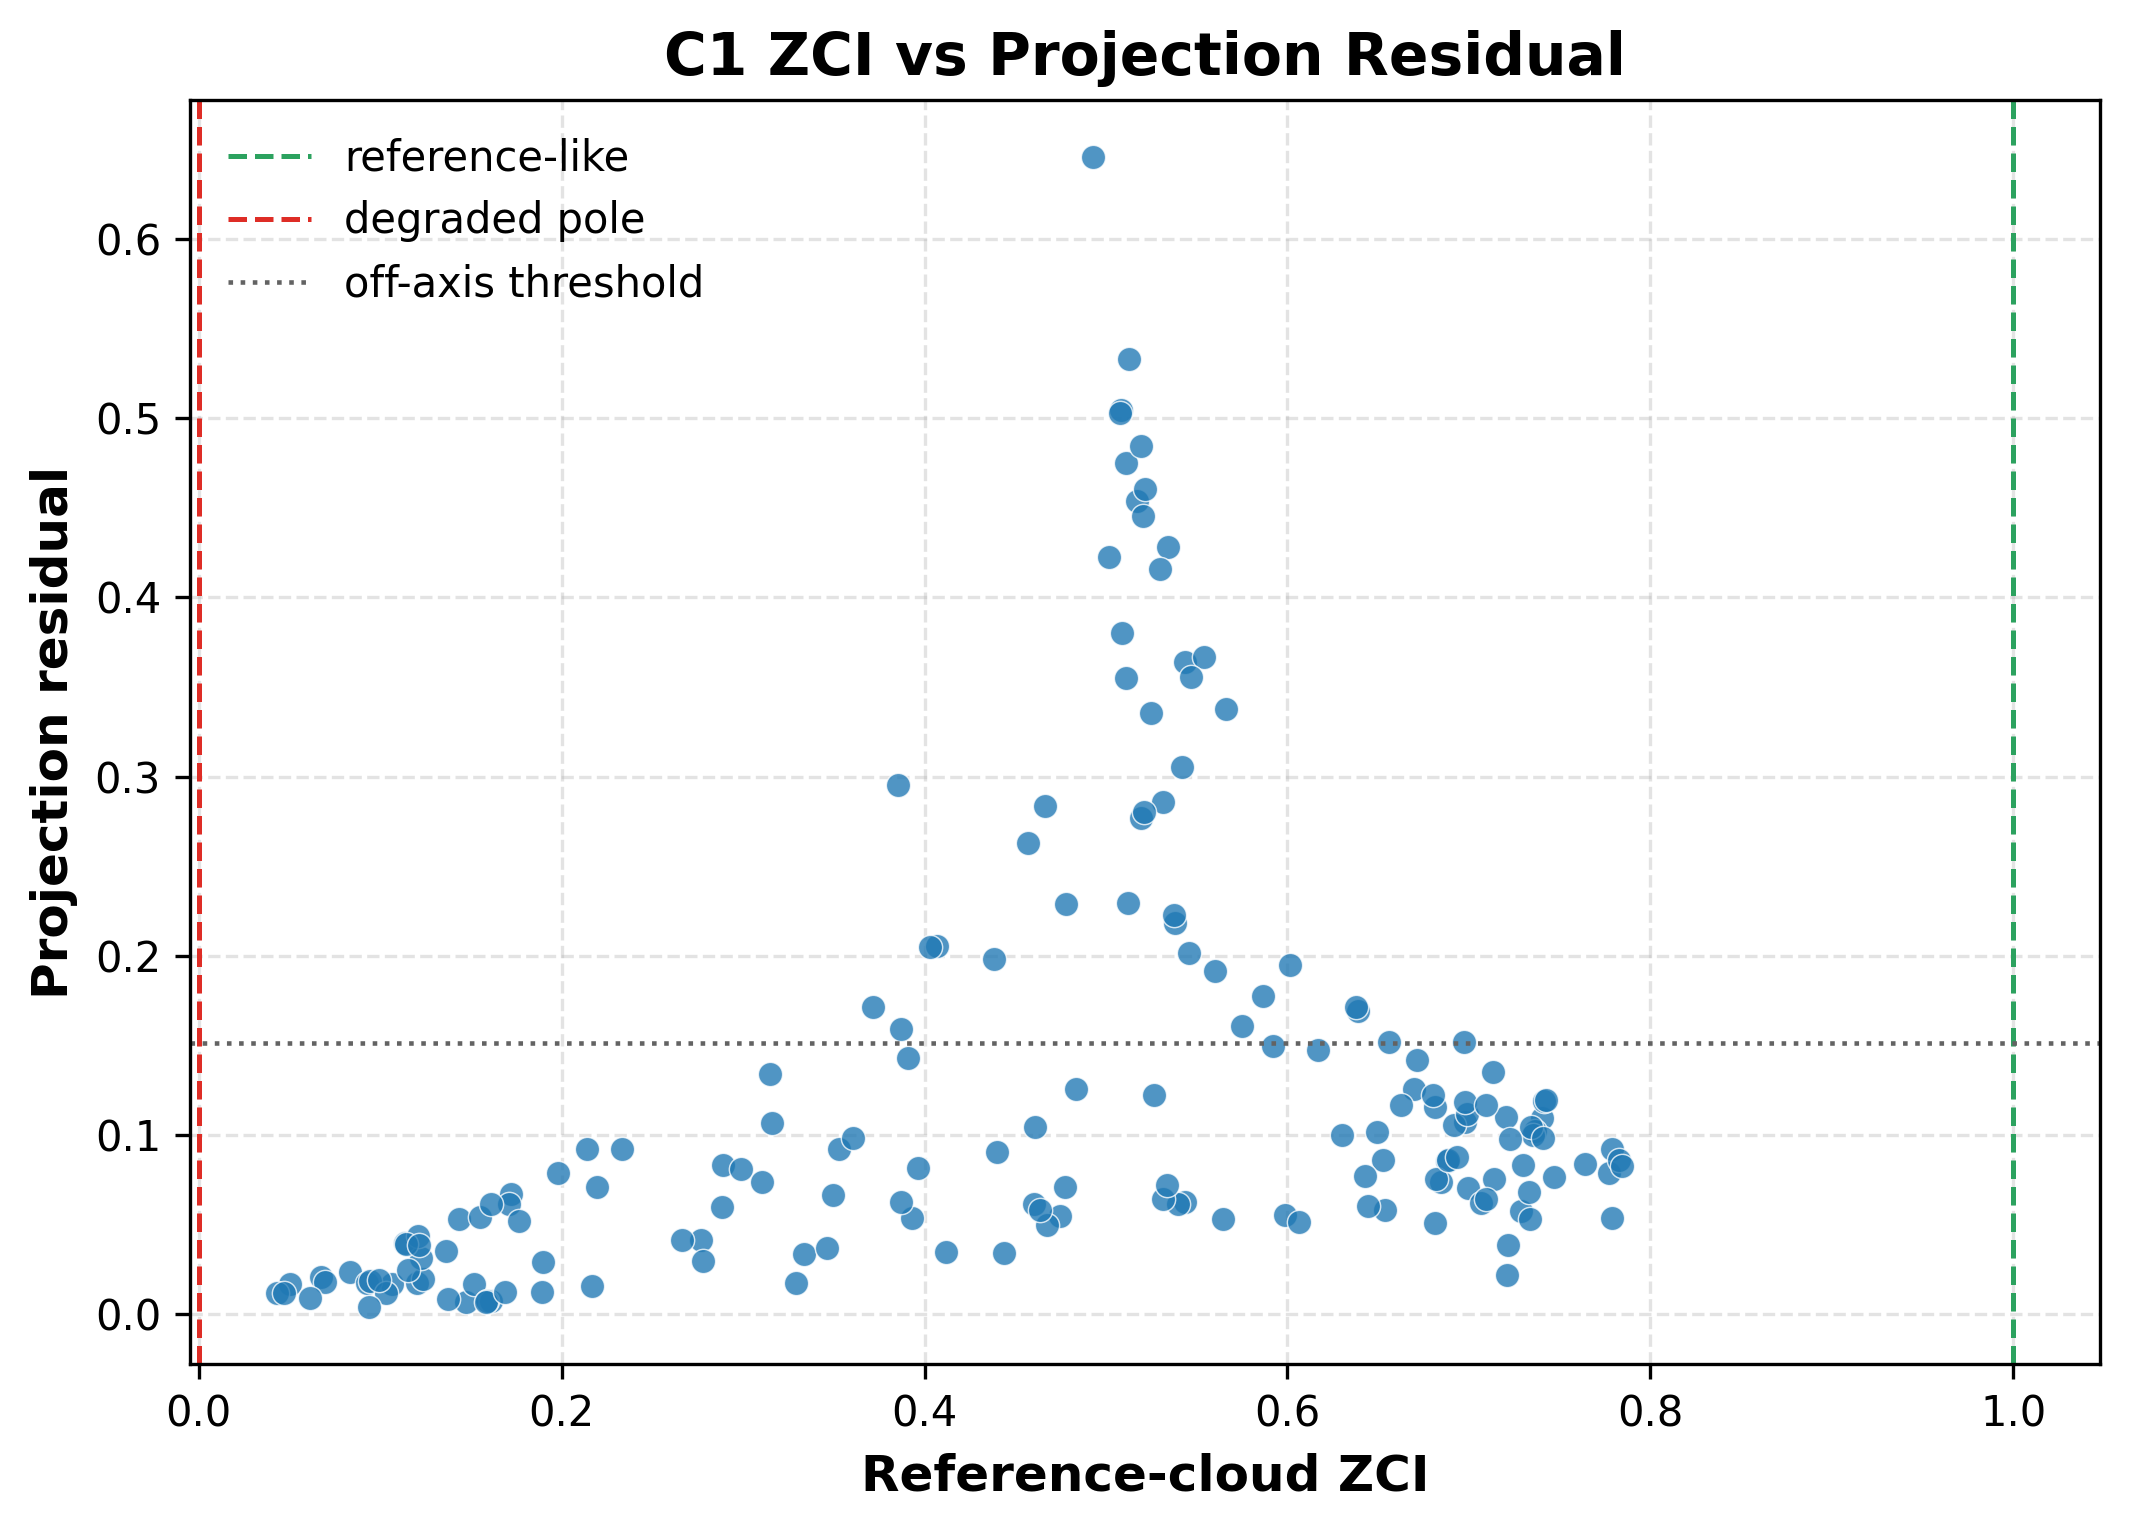

C1 ZCI 2x2 diagnostic scatter plot


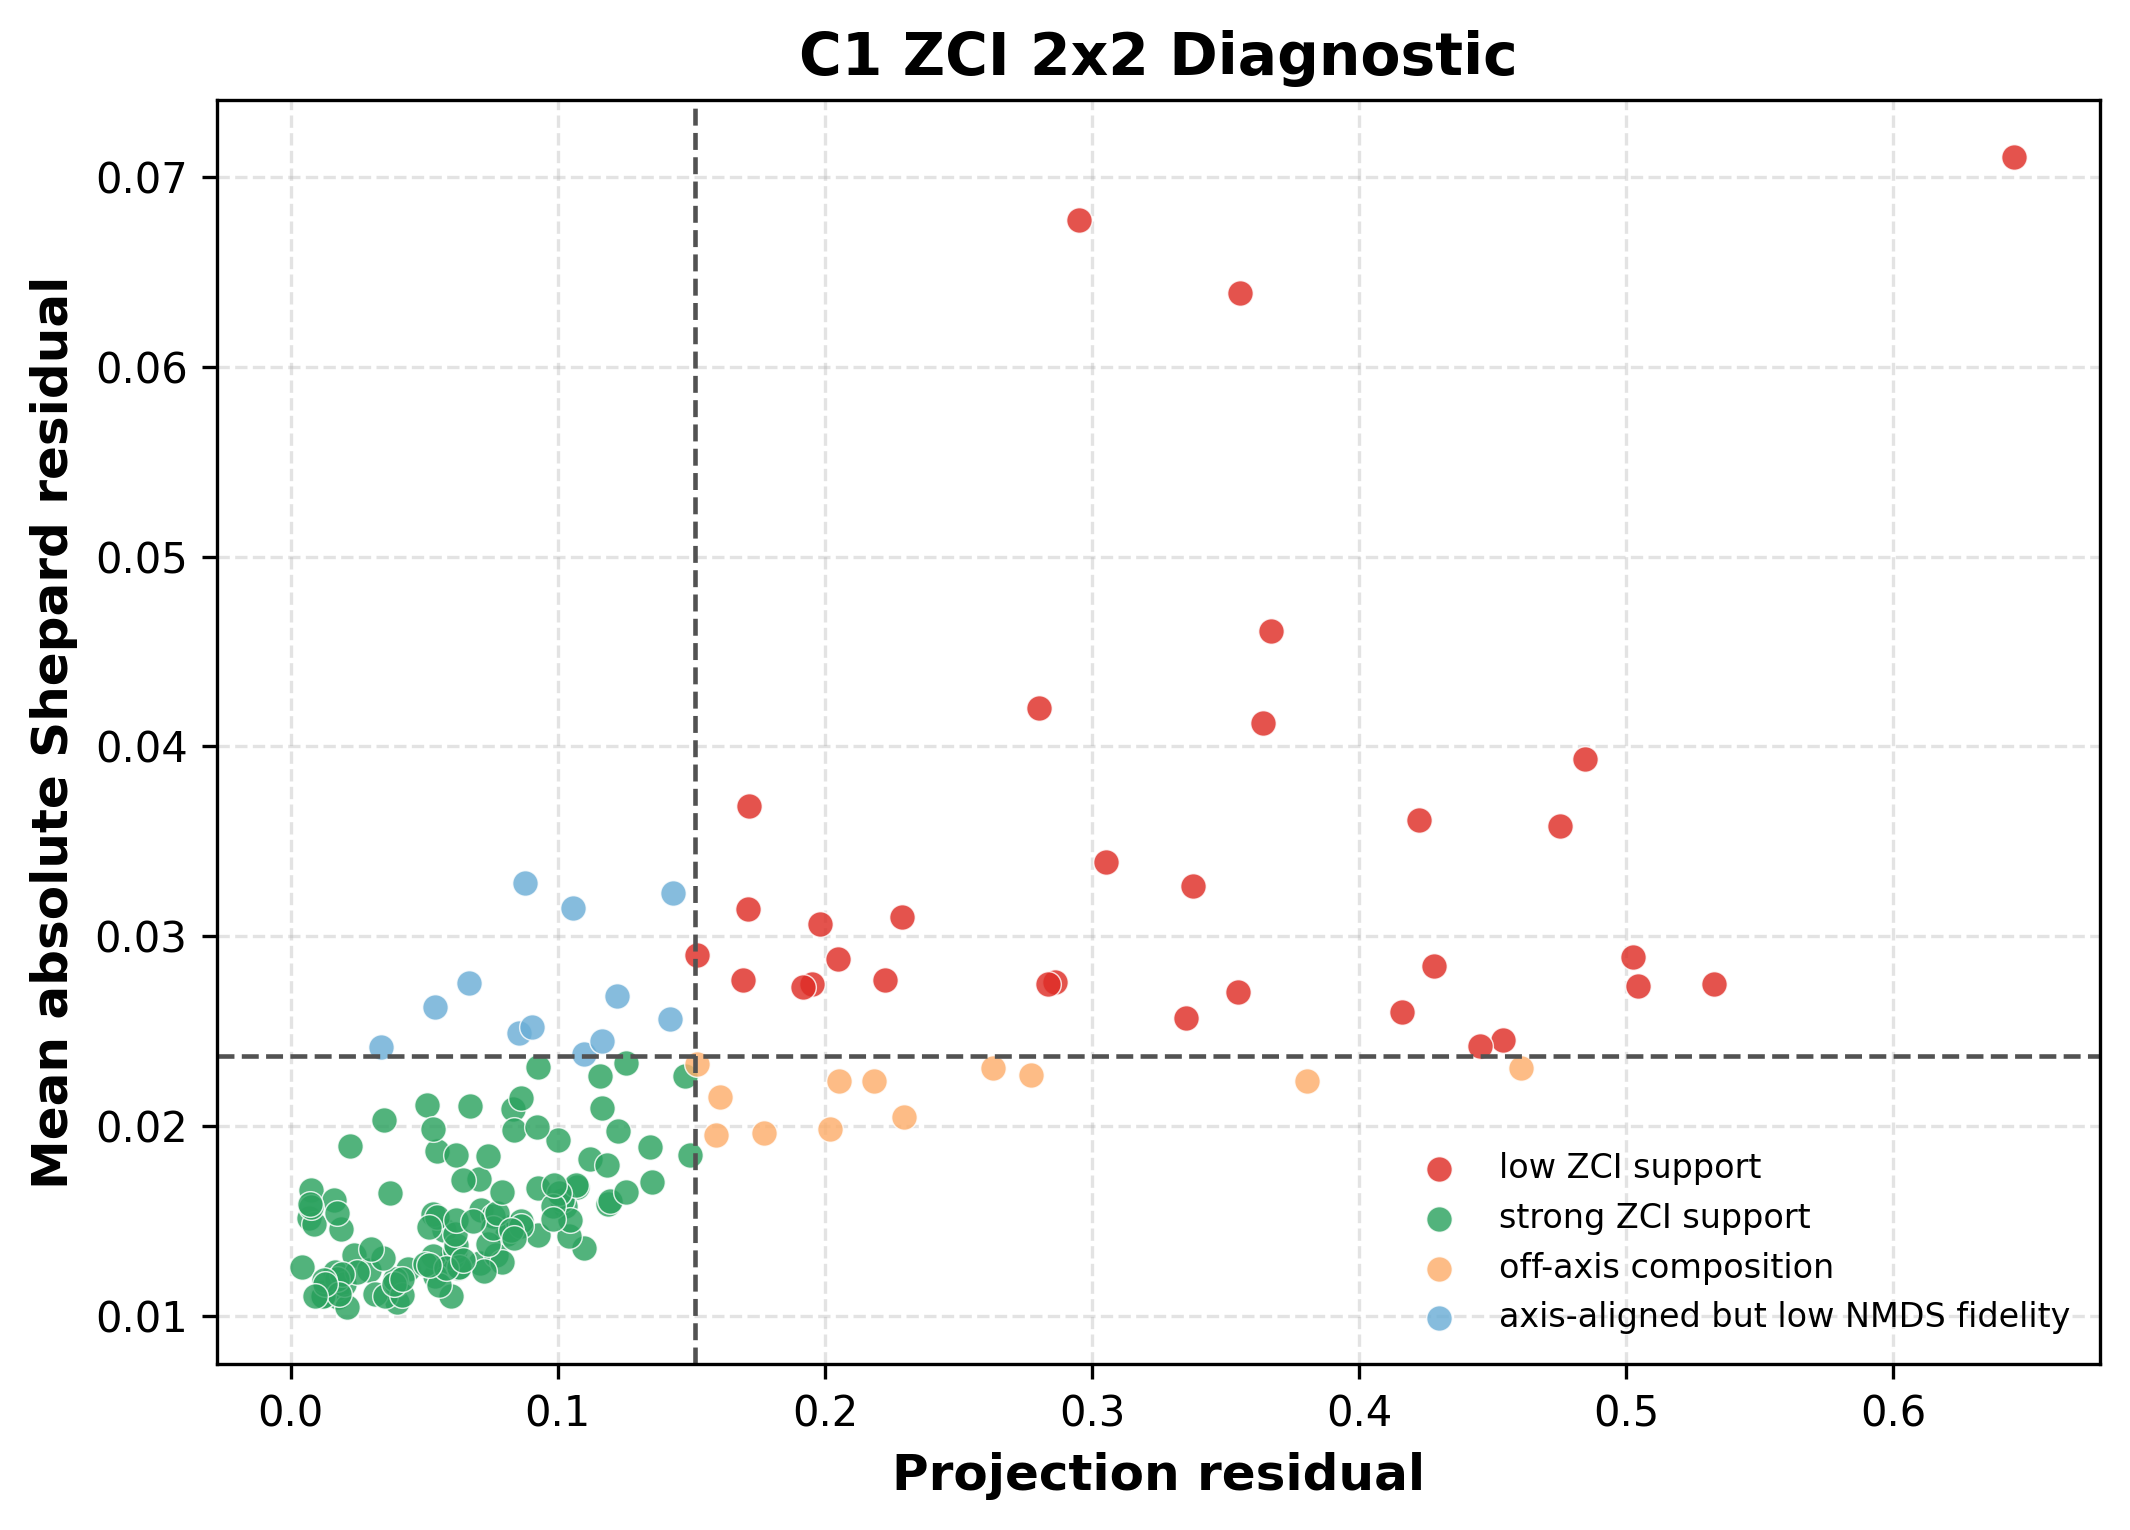

C2 ZCI vs projection residual scatter plot


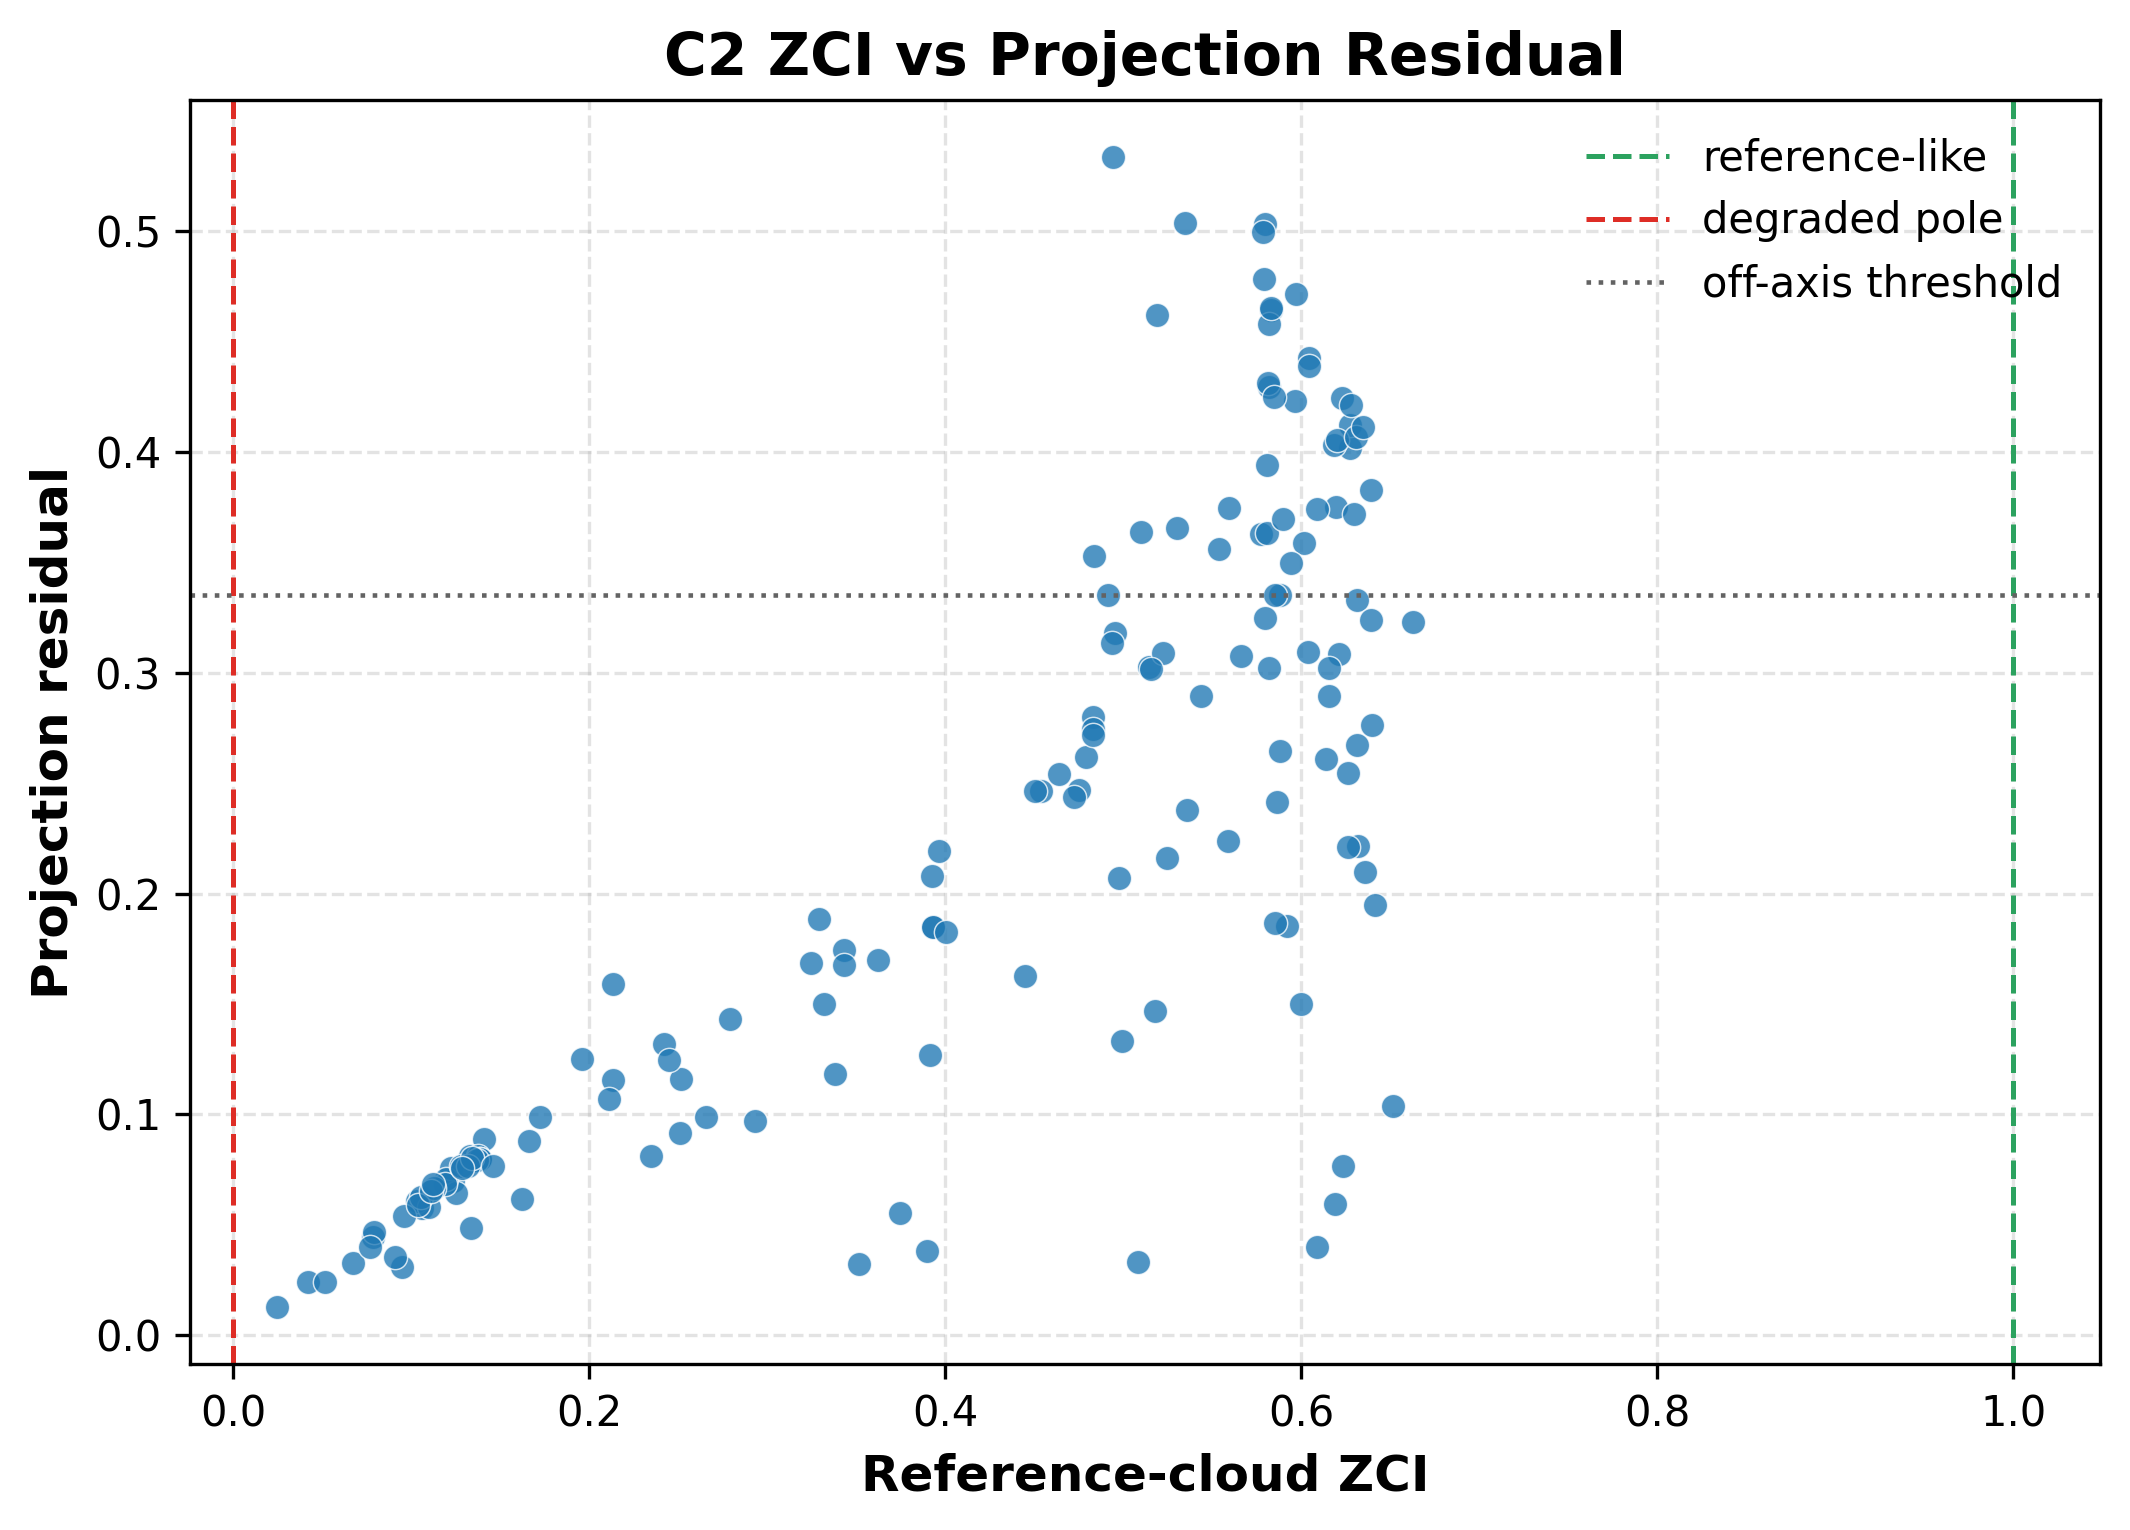

C2 ZCI 2x2 diagnostic scatter plot


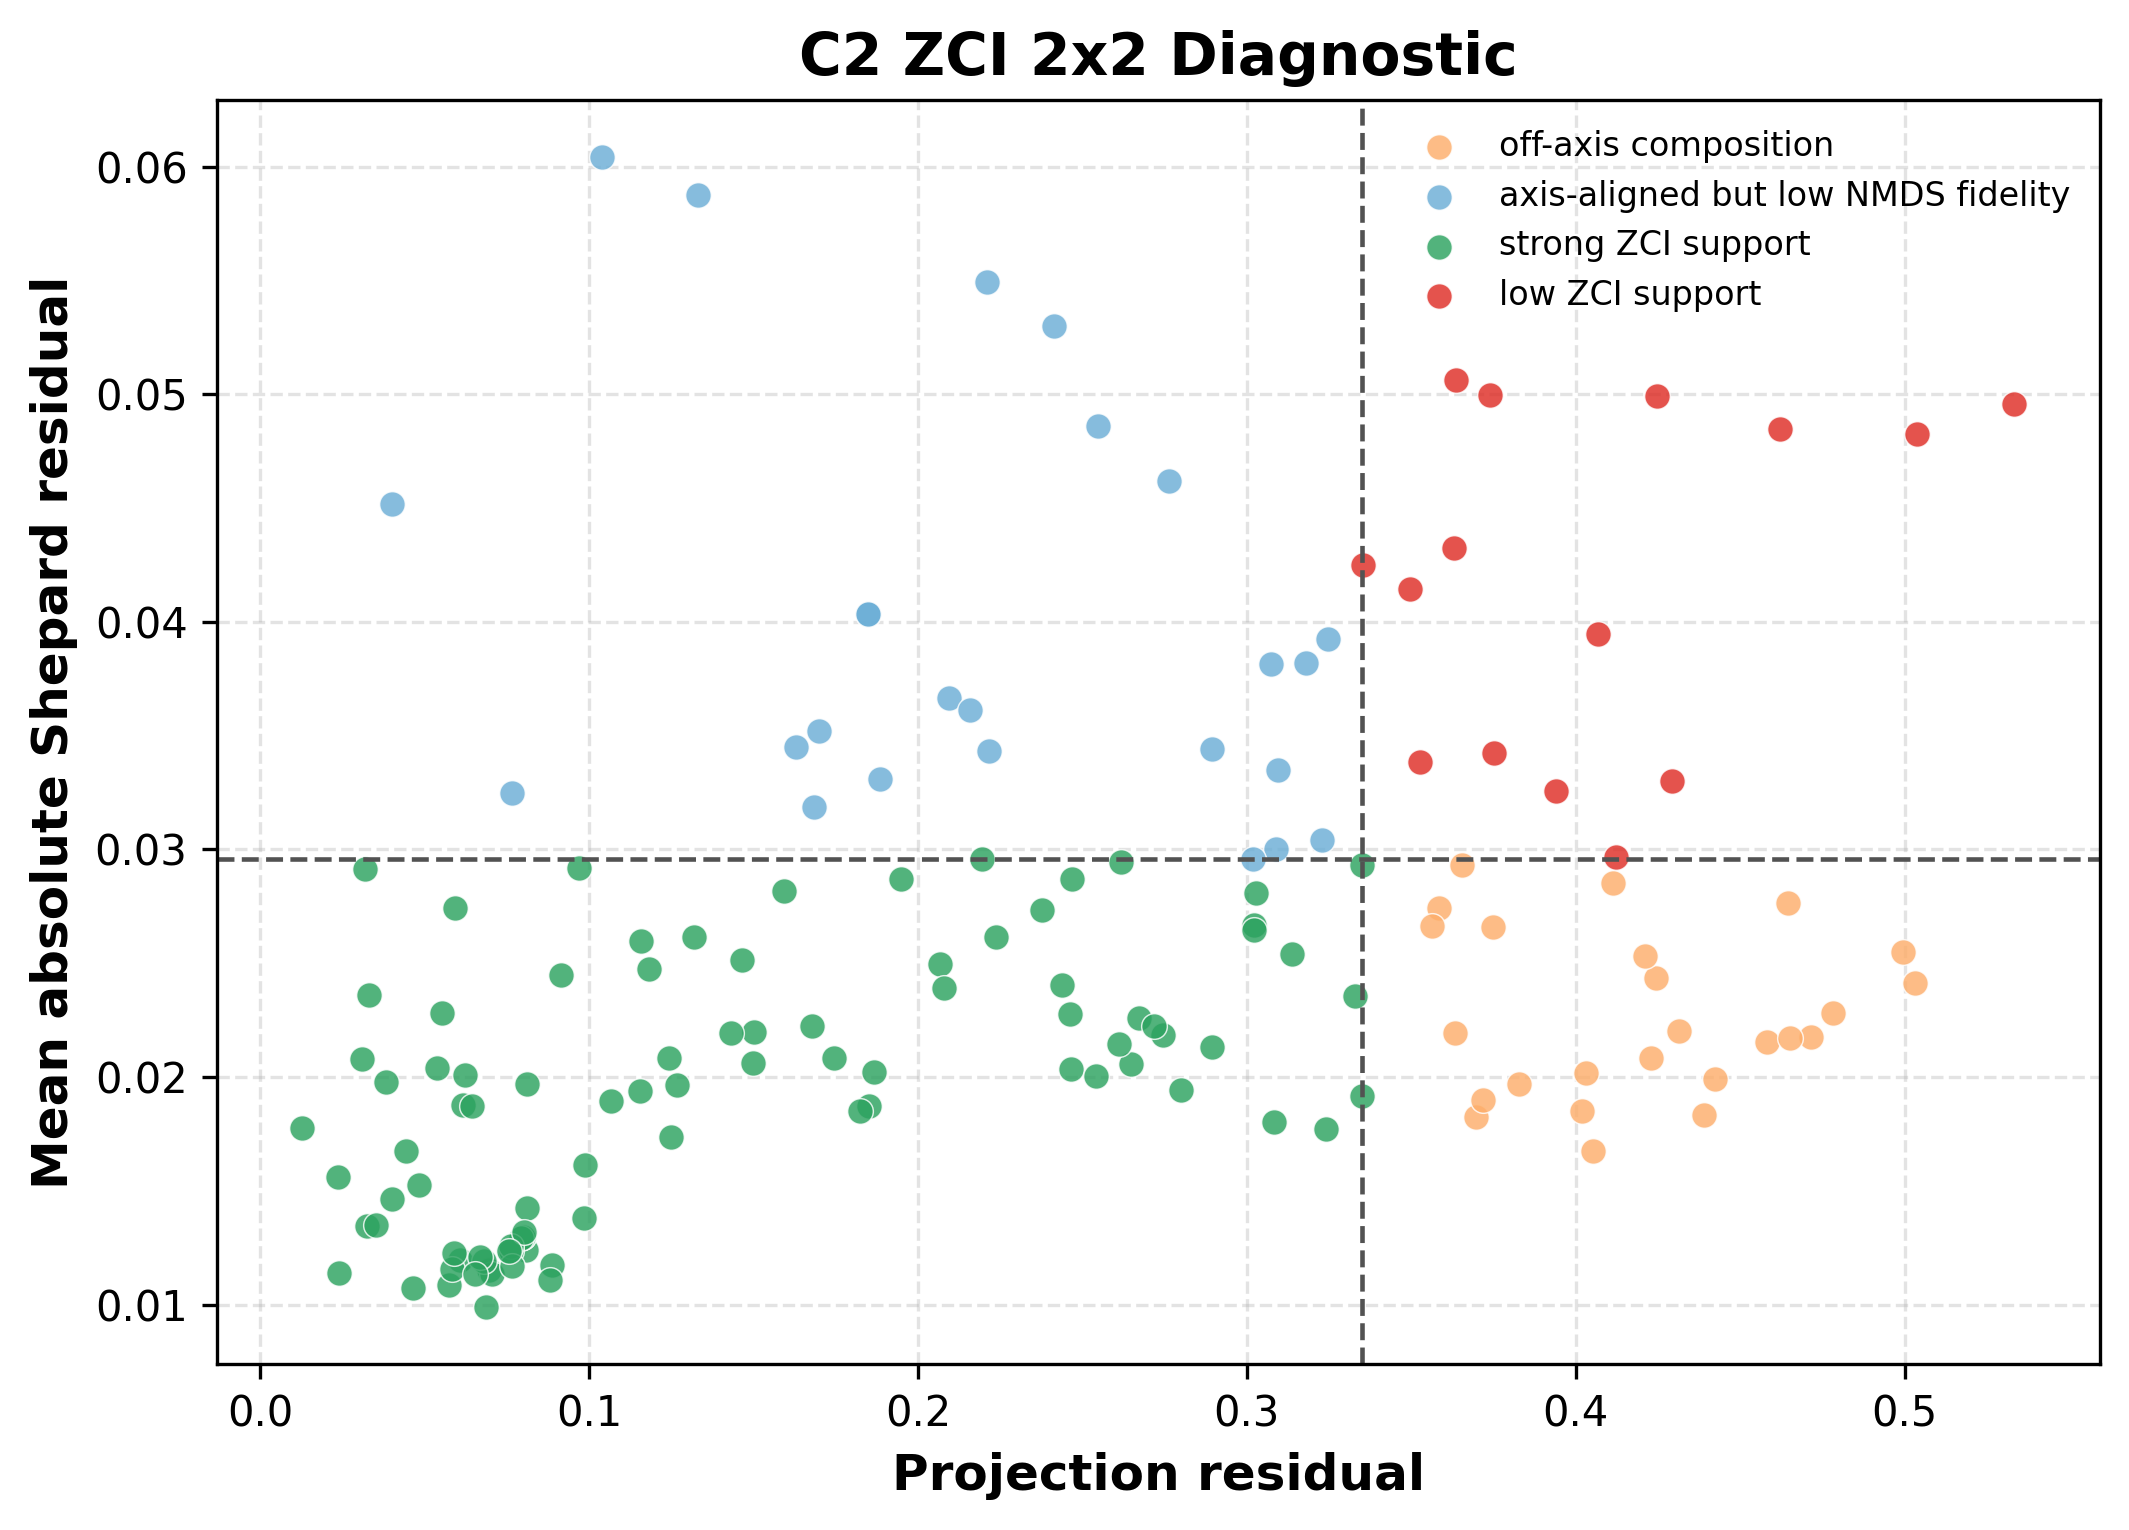

In [23]:
for cluster_label in CLUSTER_LABELS:
    zci_table = cluster_zci_tables[cluster_label]
    print(f"{cluster_label} reference-cloud ZCI table; Shape: {zci_table.shape[0]} sites x {zci_table.shape[1]} columns")
    display(zci_table.head())

print(f"Reference-cloud candidate diagnostic; Shape: {reference_cloud_diagnostic_table.shape[0]} candidates x {reference_cloud_diagnostic_table.shape[1]} columns")
display(reference_cloud_diagnostic_table.head())

print(f"ZCI 2x2 diagnostic summary; Shape: {zci_2x2_summary_table.shape[0]} rows x {zci_2x2_summary_table.shape[1]} columns")
display(zci_2x2_summary_table.head())

for cluster_label in CLUSTER_LABELS:
    print(f"{cluster_label} ZCI vs projection residual scatter plot")
    display(cluster_zci_vs_residual_figures[cluster_label])
    plt.close(cluster_zci_vs_residual_figures[cluster_label])
    print(f"{cluster_label} ZCI 2x2 diagnostic scatter plot")
    display(cluster_zci_2x2_diagnostic_figures[cluster_label])
    plt.close(cluster_zci_2x2_diagnostic_figures[cluster_label])

# Review-only save lines. Uncomment after confirming the table schema and diagnostic interpretation.
with pd.ExcelWriter(ARTIFACT_DIR / "A9_reference_cloud_ZCI_table.xlsx") as writer:
    for cluster_label in CLUSTER_LABELS:
        cluster_zci_tables[cluster_label].to_excel(writer, sheet_name=f"cluster_{cluster_label}", index=False)
    reference_cloud_diagnostic_table.to_excel(writer, sheet_name="reference_cloud_diagnostic", index=False)
    zci_2x2_summary_table.to_excel(writer, sheet_name="zci_2x2_summary", index=False)

for cluster_label in CLUSTER_LABELS:
    cluster_zci_vs_residual_figures[cluster_label].savefig(
        FIGURE_DIR / f"ch4_fw3_{cluster_label}_zci_vs_projection_residual.png",
        dpi=300,
        bbox_inches="tight",
    )
    cluster_zci_2x2_diagnostic_figures[cluster_label].savefig(
        FIGURE_DIR / f"ch4_fw3_{cluster_label}_zci_2x2_diagnostic.png",
        dpi=300,
        bbox_inches="tight",
    )

## Supplementary Visualization: Reference-Cloud ZCI vs Contamination Scores

C1 reference-cloud ZCI vs SumRel scatter plot; matched 174 sites


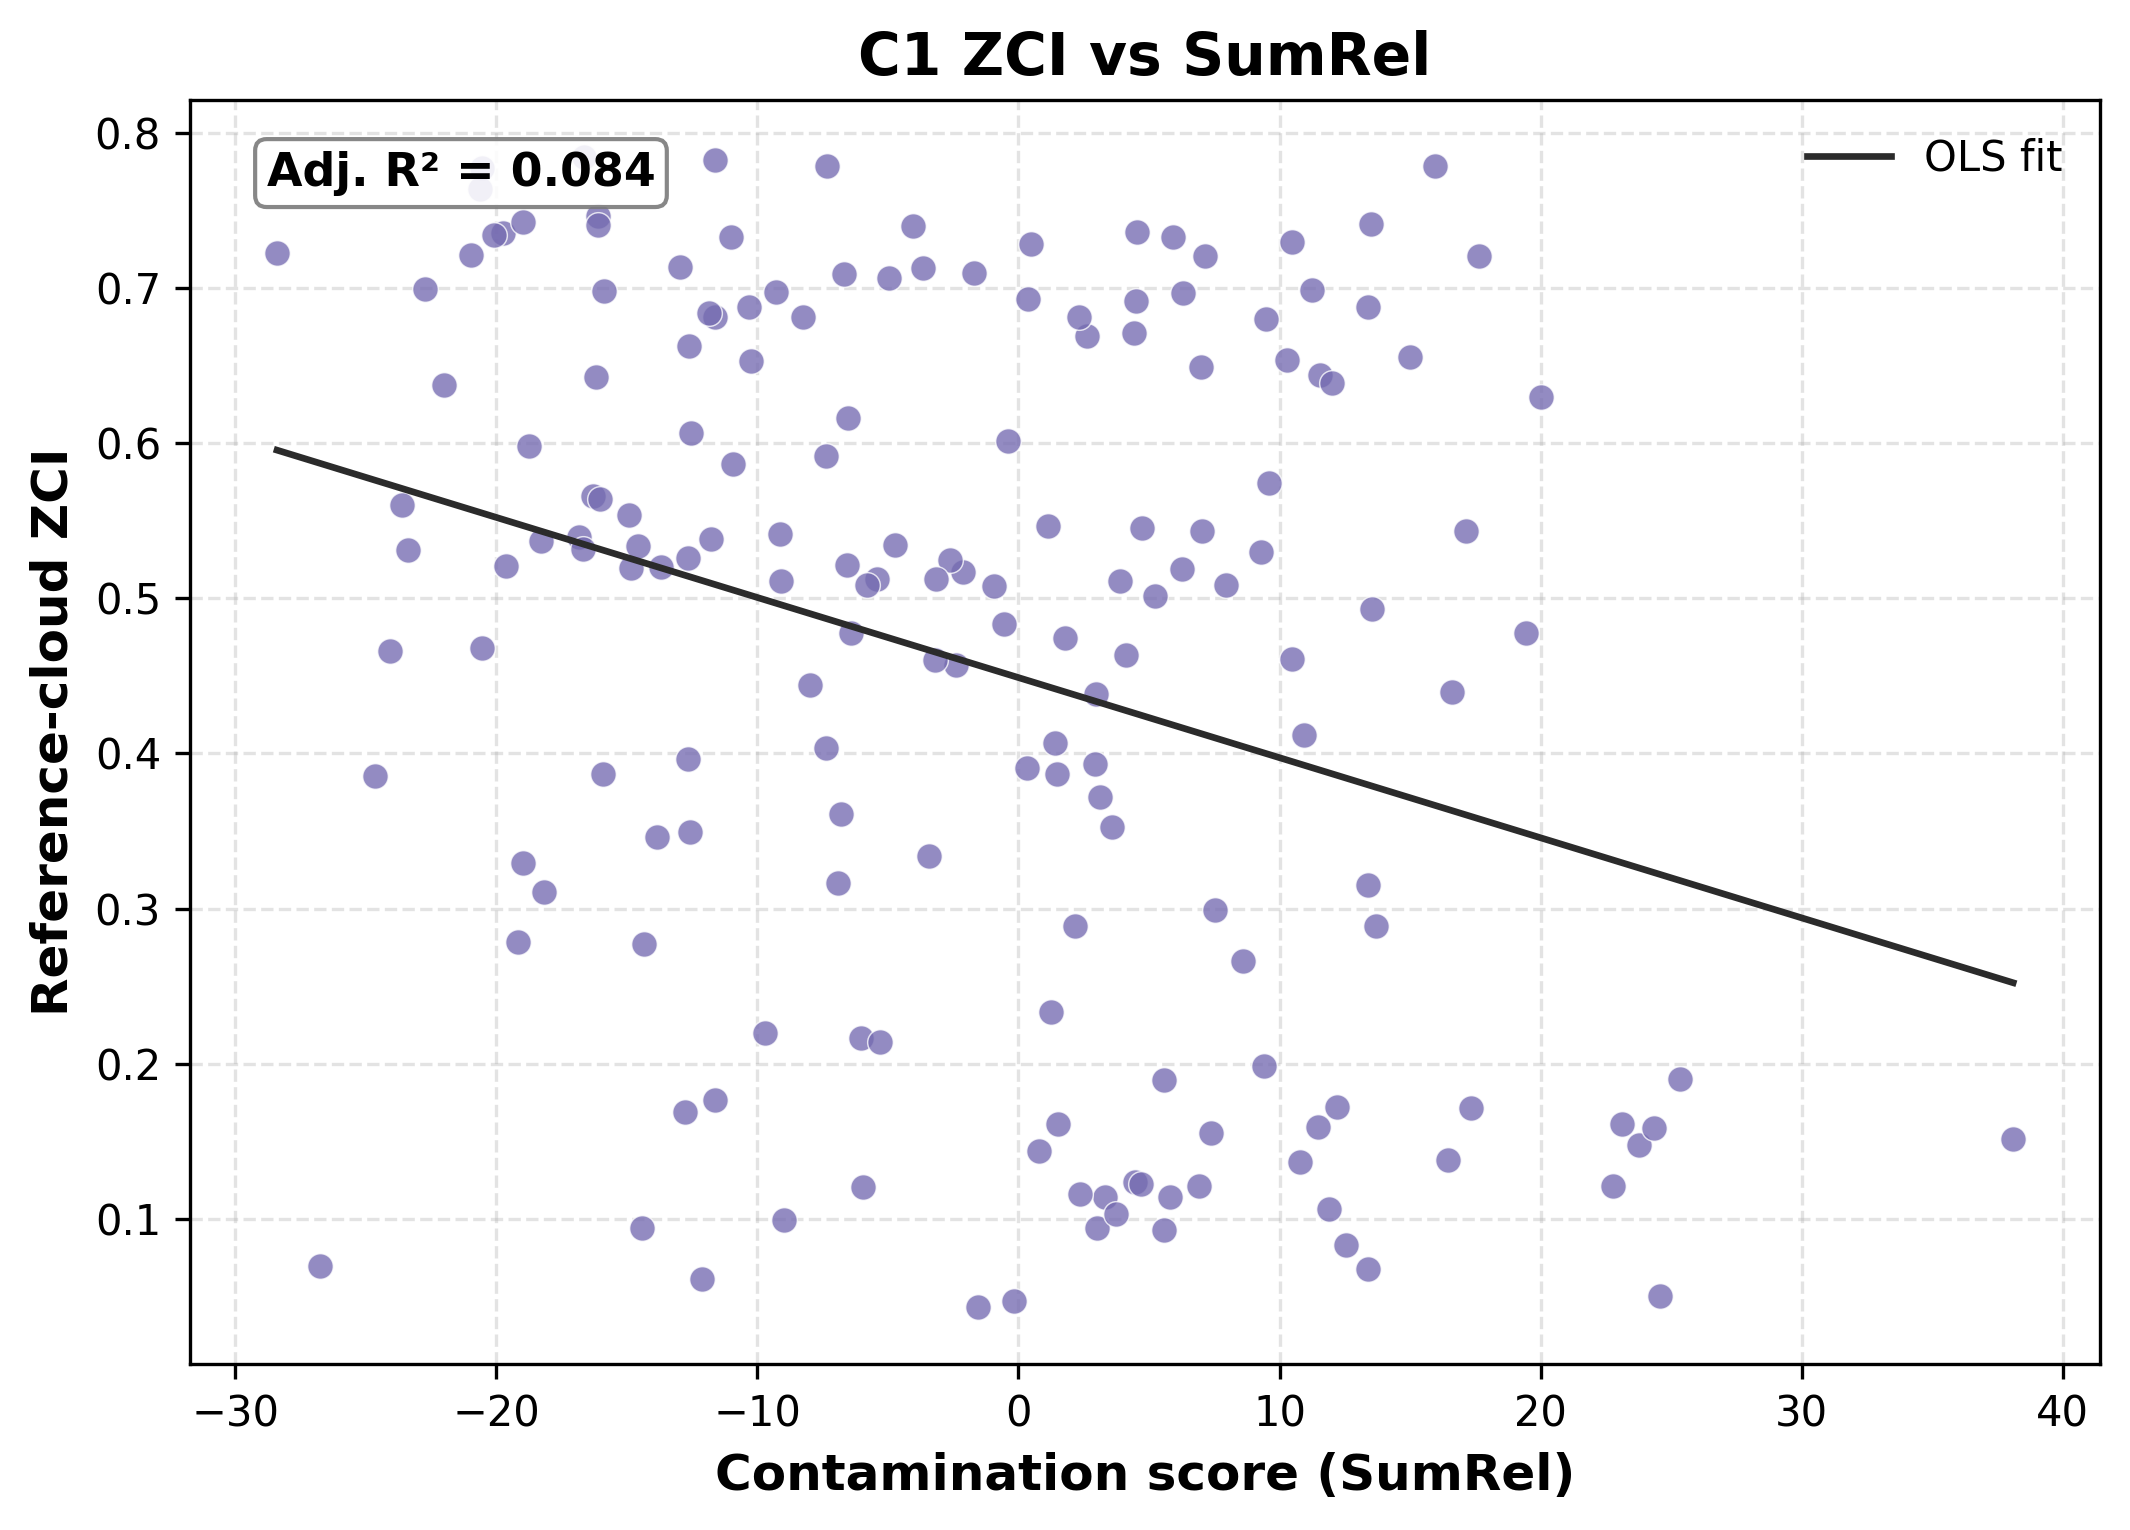

C2 reference-cloud ZCI vs SumRel scatter plot; matched 161 sites


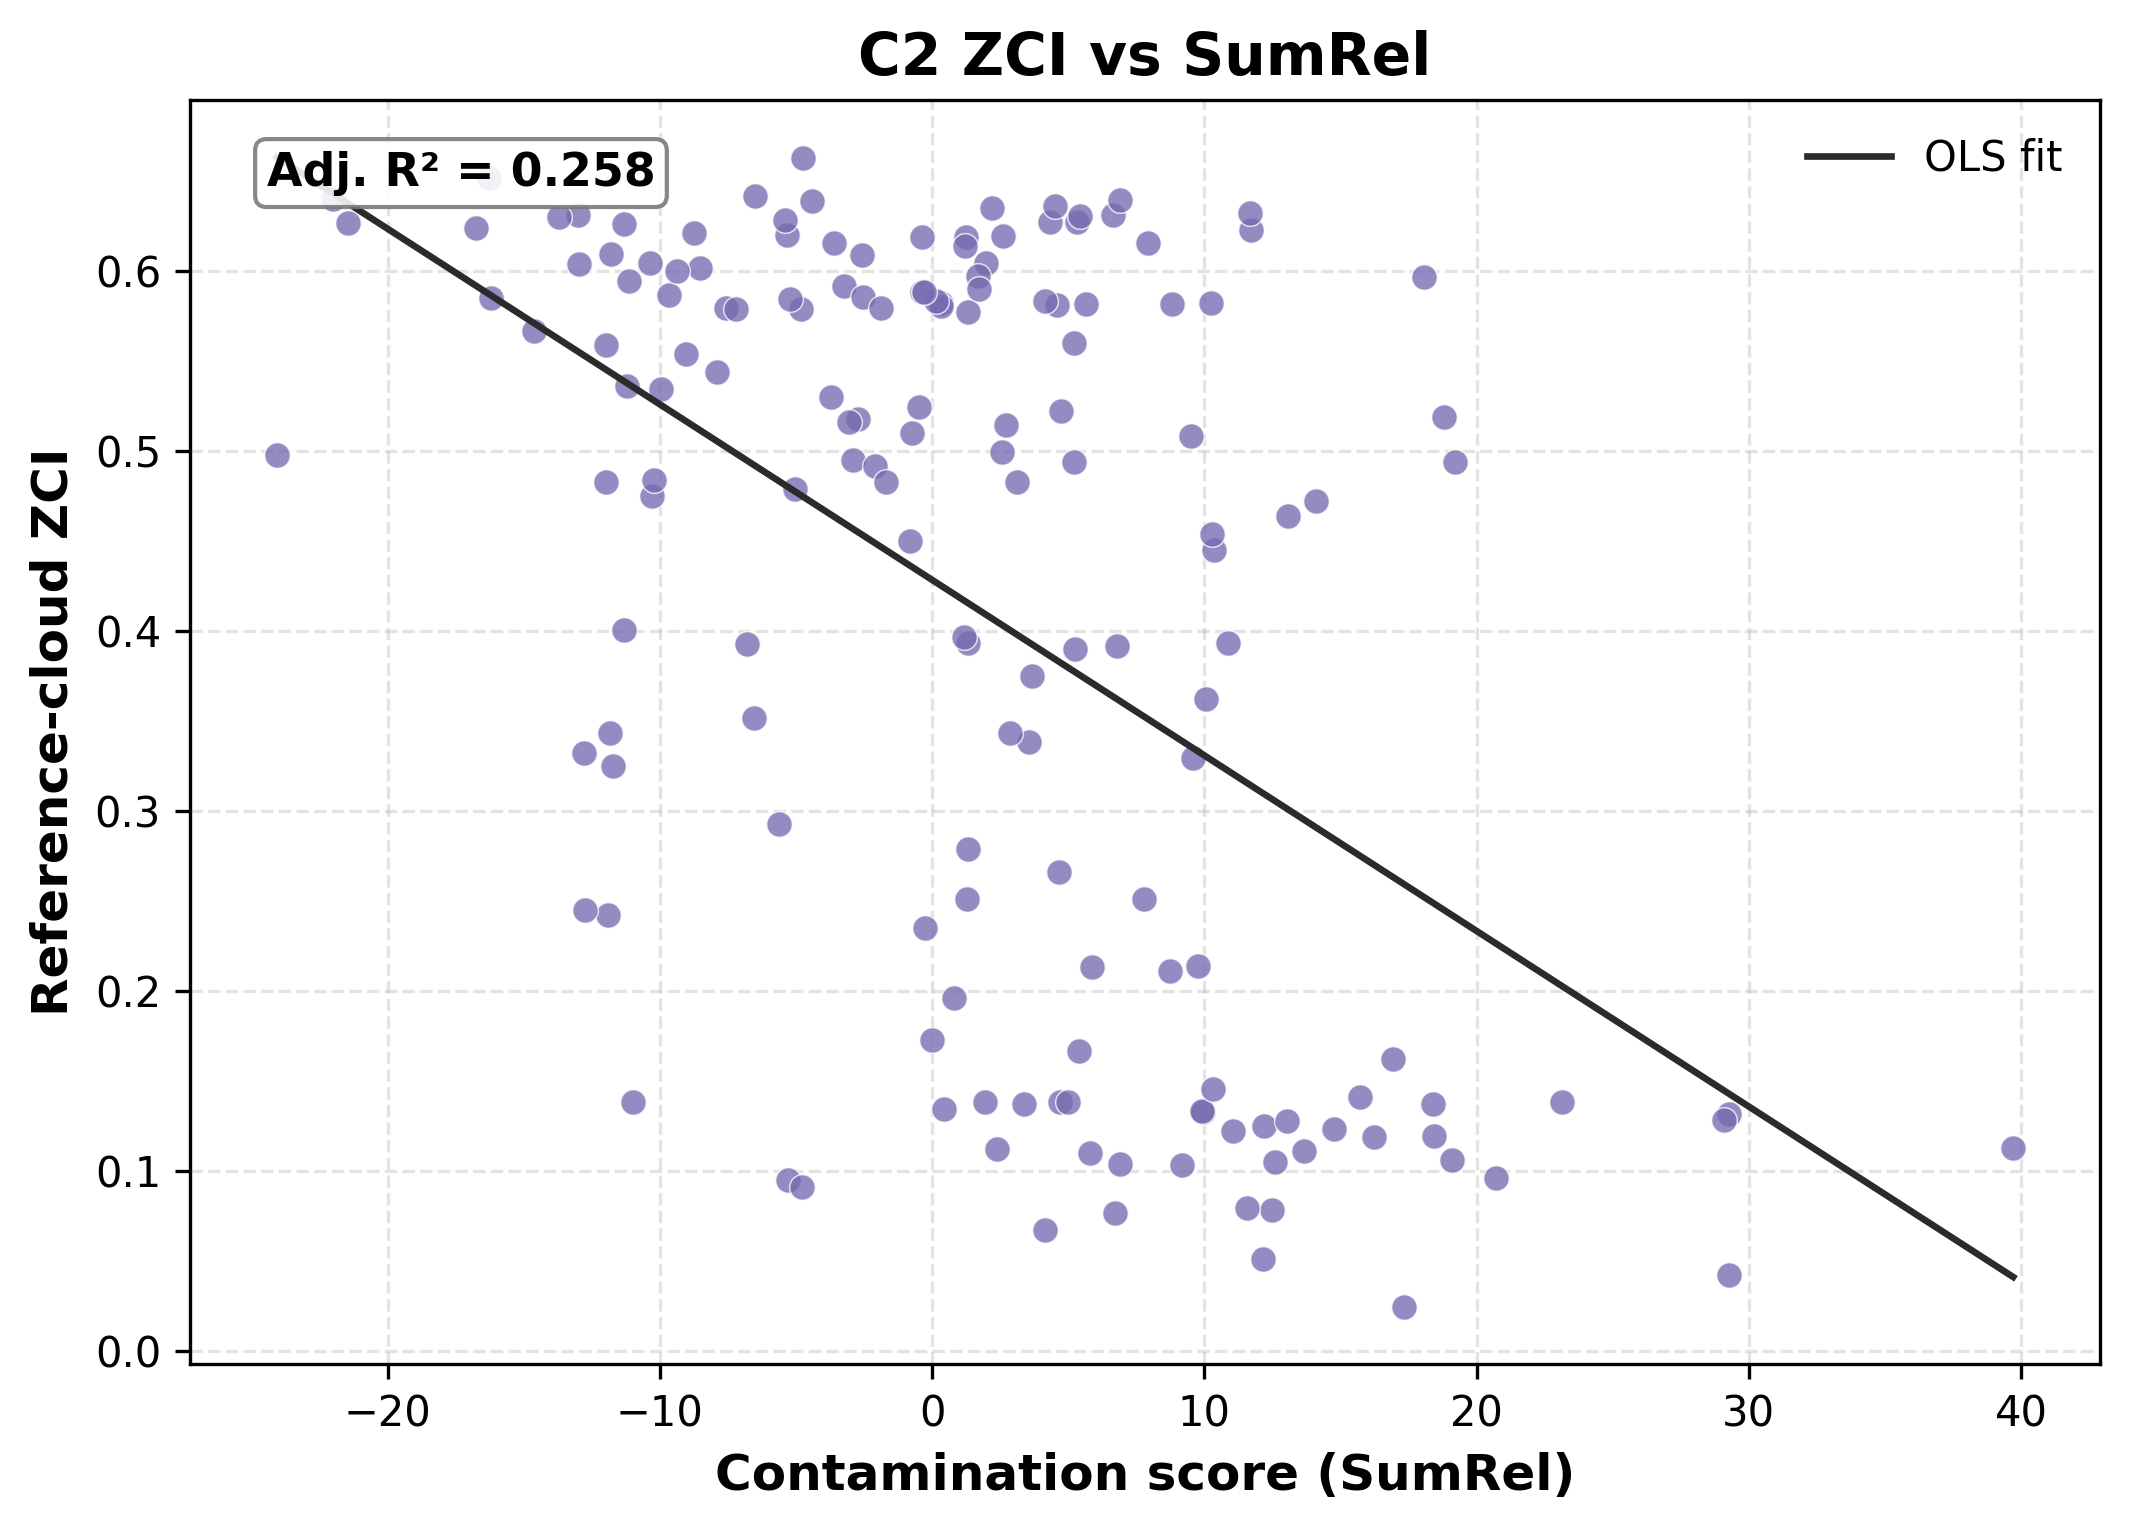

In [22]:
cluster_zci_stressor_tables = {
    cluster_label: build_zci_stressor_table(
        cluster_zci_tables[cluster_label],
        score_col=CONTAMINATION_SCORE,
        id_col=SITE_ID_COLUMN,
    )
    for cluster_label in CLUSTER_LABELS
}

cluster_zci_vs_contamination_figures: dict[str, plt.Figure] = {}
with plt.ioff():
    for cluster_label, zci_stressor_table in cluster_zci_stressor_tables.items():
        zci_vs_contamination_figure, _ = render_zci_vs_contamination_figure(
            zci_stressor_table,
            cluster_label=cluster_label,
            score_col=CONTAMINATION_SCORE,
        )
        cluster_zci_vs_contamination_figures[cluster_label] = zci_vs_contamination_figure
        globals()[f"c{cluster_label.removeprefix('C')}_zci_stressor_scores"] = zci_stressor_table
        globals()[f"c{cluster_label.removeprefix('C')}_zci_vs_contamination_scores"] = zci_vs_contamination_figure

for cluster_label in CLUSTER_LABELS:
    zci_stressor_table = cluster_zci_stressor_tables[cluster_label]
    print(f"{cluster_label} reference-cloud ZCI vs {CONTAMINATION_SCORE} scatter plot; matched {zci_stressor_table.shape[0]} sites")
    display(cluster_zci_vs_contamination_figures[cluster_label])
    plt.close(cluster_zci_vs_contamination_figures[cluster_label])

# Review-only save lines. Uncomment after confirming the table schema and diagnostic interpretation.
# for cluster_label in CLUSTER_LABELS:
#     cluster_zci_vs_contamination_figures[cluster_label].savefig(
#         FIGURE_DIR / f"ch4_fw3_{cluster_label}_reference_cloud_zci_vs_contamination.png",
#         dpi=300,
#         bbox_inches="tight",
#     )

## Supplementary Visualization: Projection Residual vs Contamination Scores


C1 projection residual vs SumRel scatter plot; matched 174 sites


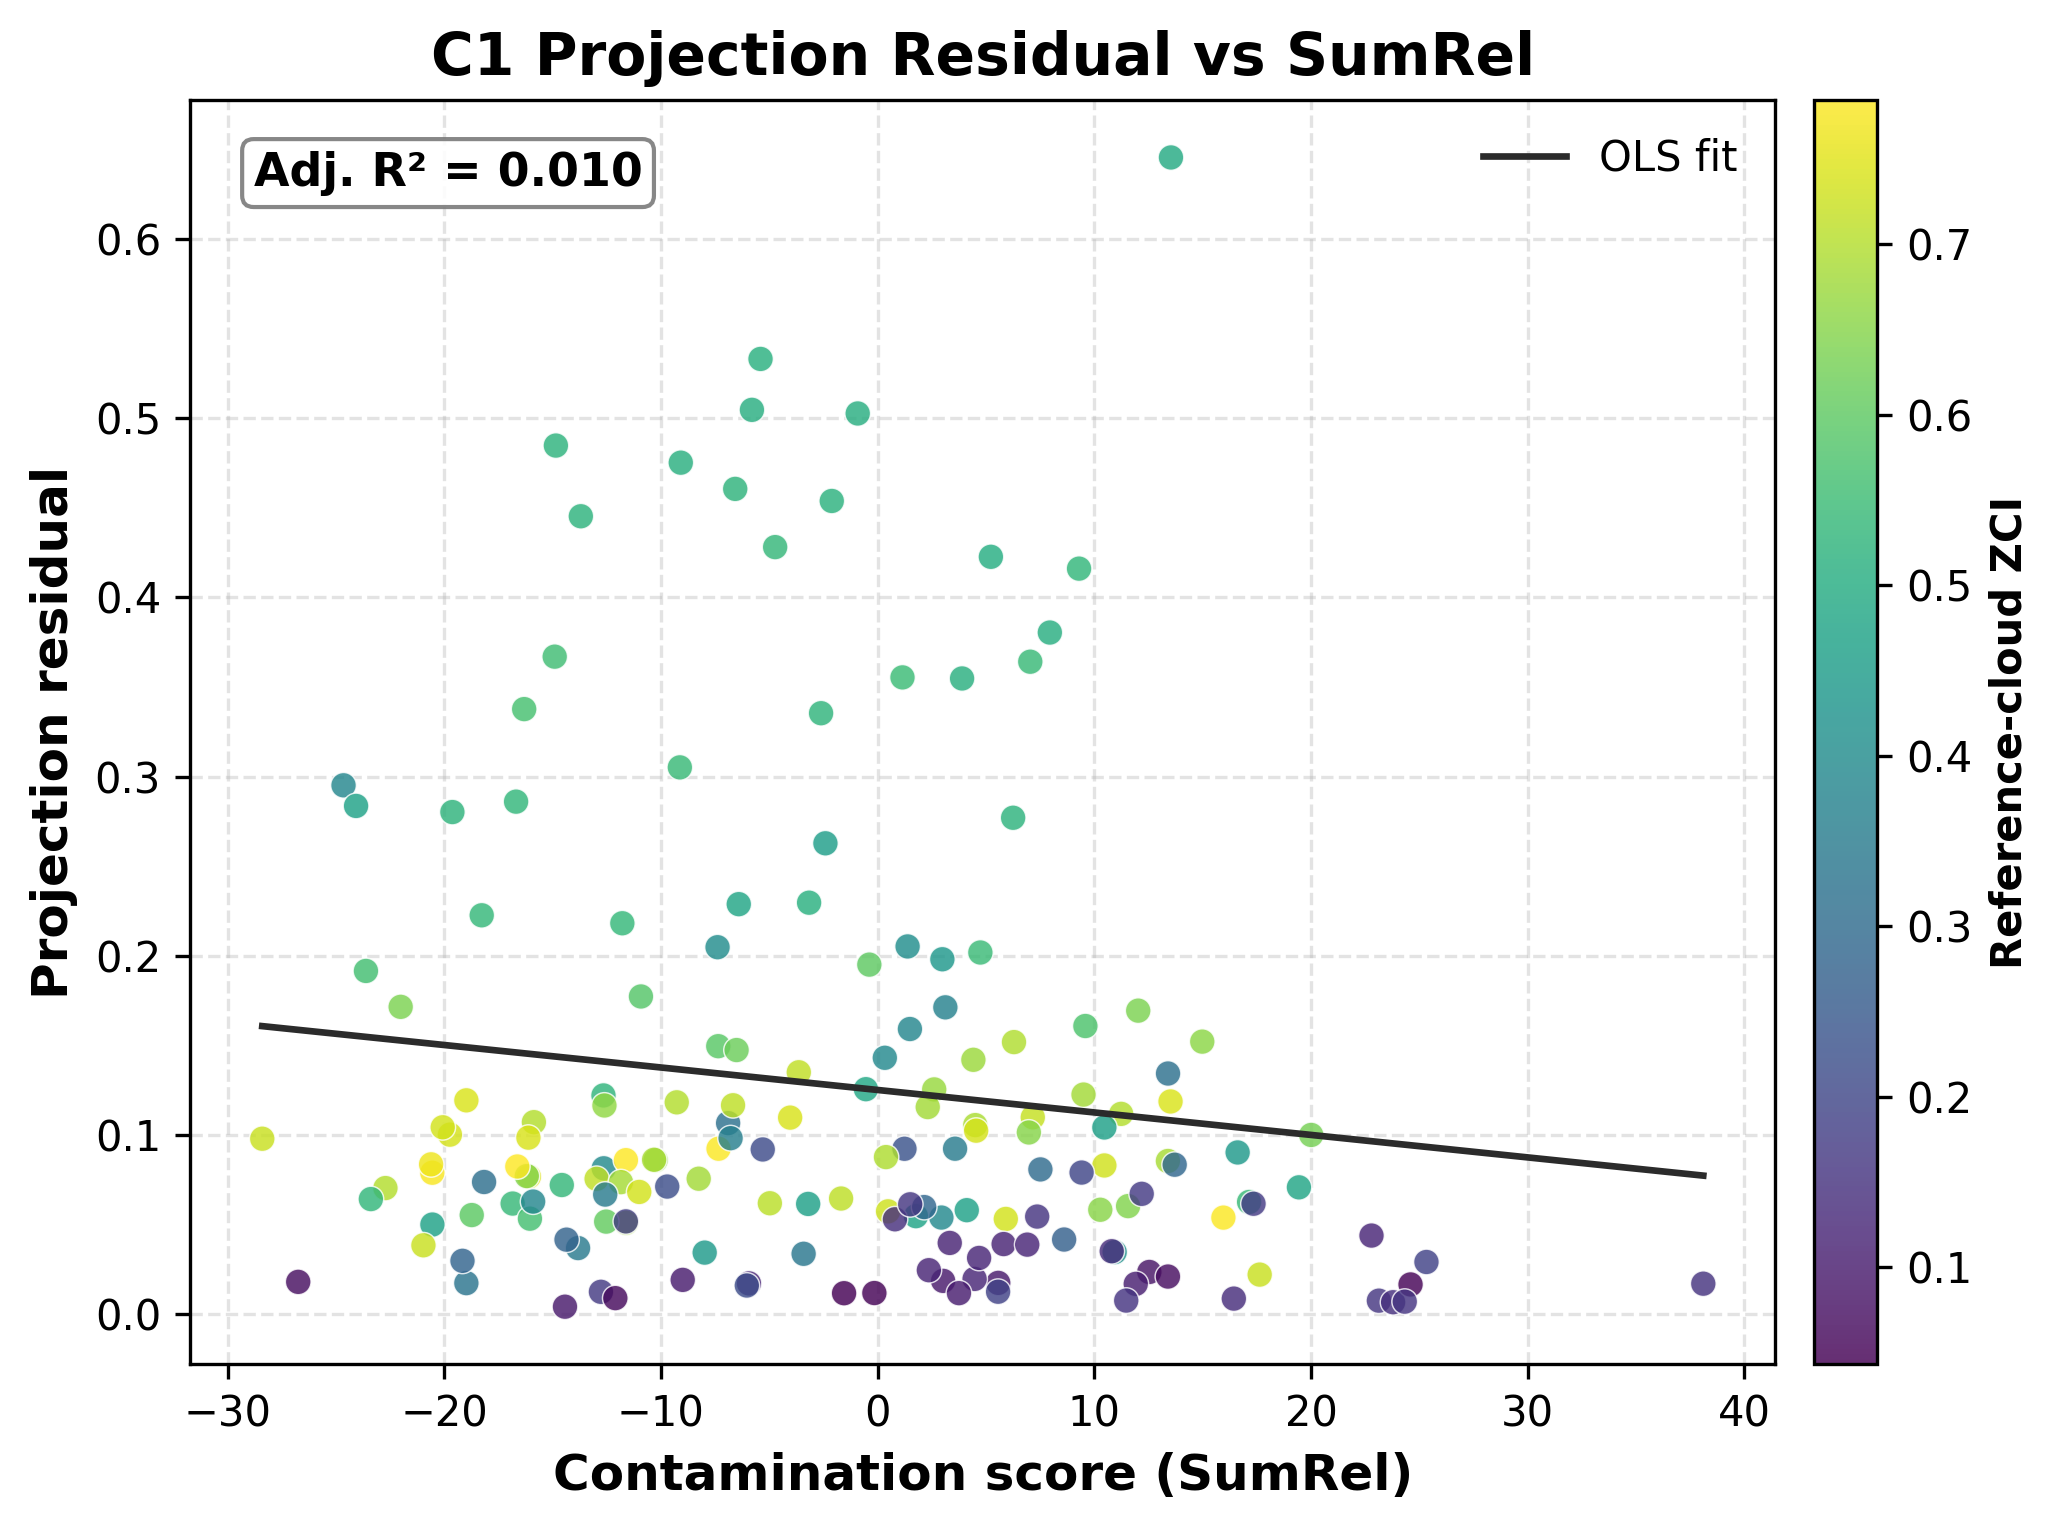

C2 projection residual vs SumRel scatter plot; matched 161 sites


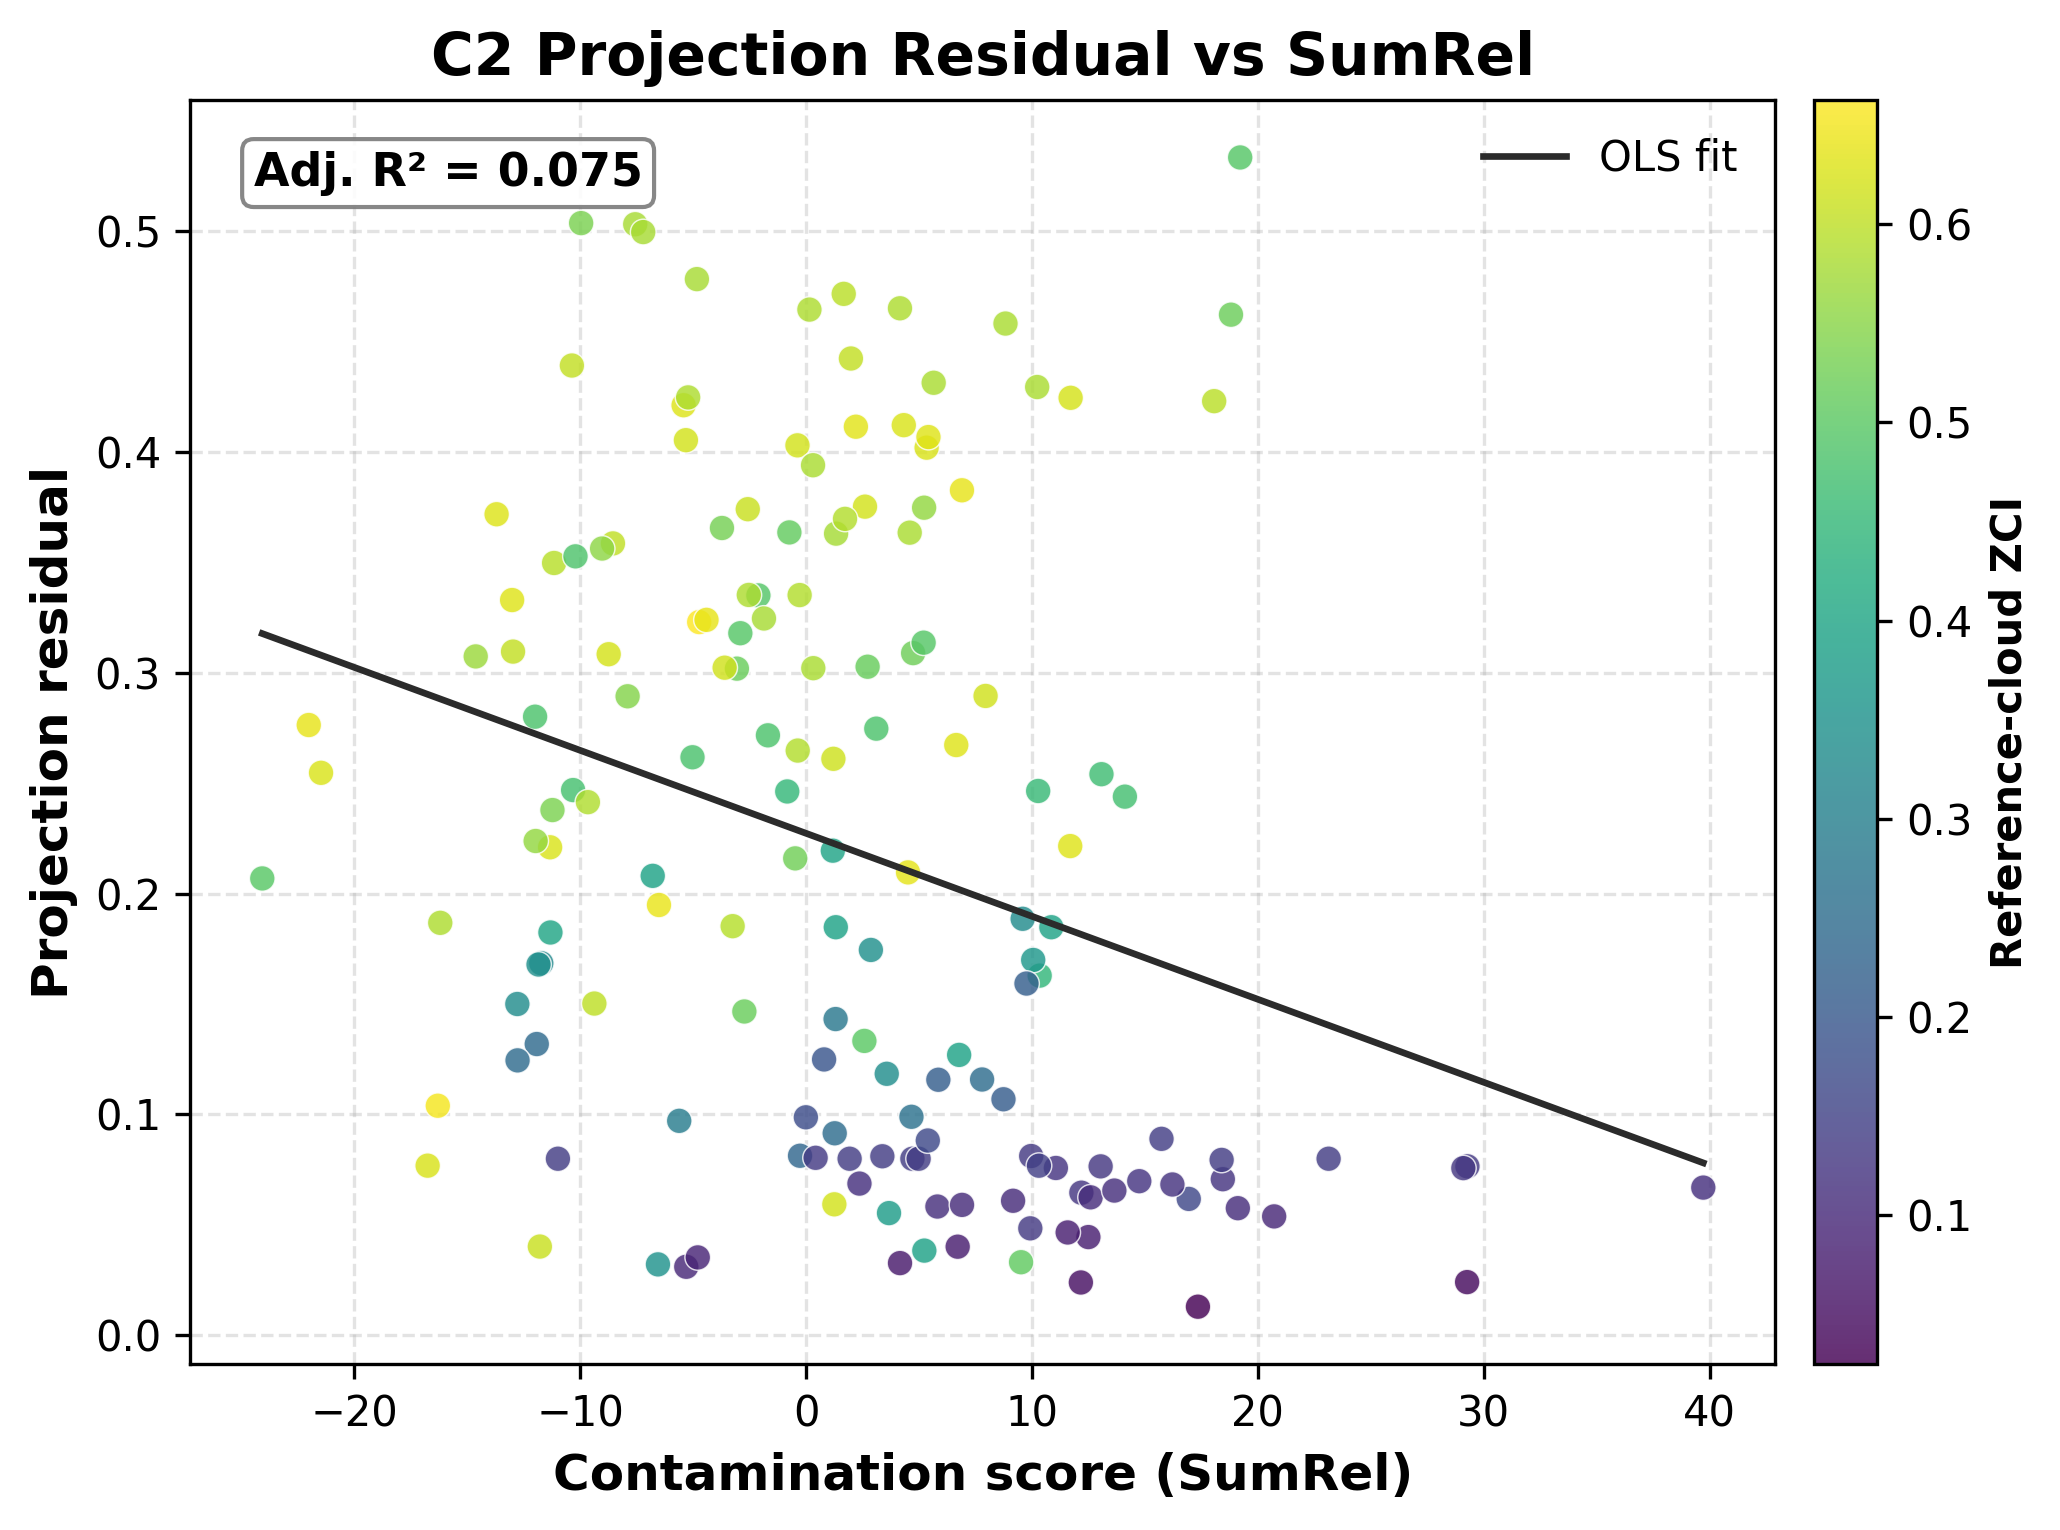

In [24]:
def render_projection_residual_vs_contamination_figure(
    zci_table: pd.DataFrame,
    cluster_label: str,
    score_col: str = CONTAMINATION_SCORE,
    dpi: int = 300,
) -> tuple[plt.Figure, plt.Axes]:
    required_columns = {score_col, "projection residual", "ZCI"}
    missing_columns = required_columns.difference(zci_table.columns)
    if missing_columns:
        raise KeyError(f"The ZCI table is missing required columns: {sorted(missing_columns)}")

    figure, axis = plt.subplots(figsize=(7.2, 5.2), dpi=dpi)
    scatter = axis.scatter(
        zci_table[score_col],
        zci_table["projection residual"],
        c=zci_table["ZCI"],
        cmap="viridis",
        s=38,
        alpha=0.82,
        edgecolor="white",
        linewidth=0.35,
    )
    colorbar = figure.colorbar(scatter, ax=axis, pad=0.02)
    colorbar.set_label("Reference-cloud ZCI", fontsize=10, fontweight="bold")

    slope, intercept, adjusted_r_squared = _fit_simple_ols_line(
        zci_table[score_col],
        zci_table["projection residual"],
    )
    x_min = float(pd.to_numeric(zci_table[score_col], errors="coerce").min())
    x_max = float(pd.to_numeric(zci_table[score_col], errors="coerce").max())
    line_x = np.linspace(x_min, x_max, 100)
    line_y = intercept + slope * line_x
    axis.plot(line_x, line_y, color="#2b2b2b", linewidth=1.6, label="OLS fit")
    axis.text(
        0.04,
        0.96,
        f"Adj. R² = {adjusted_r_squared:.3f}",
        transform=axis.transAxes,
        ha="left",
        va="top",
        fontsize=11,
        fontweight="bold",
        bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "#777777", "alpha": 0.88},
    )
    axis.set_xlabel(f"Contamination score ({score_col})", fontsize=12, fontweight="bold")
    axis.set_ylabel("Projection residual", fontsize=12, fontweight="bold")
    axis.set_title(f"{cluster_label} Projection Residual vs {score_col}", fontsize=14, fontweight="bold")
    axis.grid(True, linestyle="--", linewidth=0.8, alpha=0.35)
    axis.set_axisbelow(True)
    axis.legend(frameon=False)
    figure.tight_layout()
    return figure, axis


cluster_projection_residual_vs_contamination_figures: dict[str, plt.Figure] = {}
with plt.ioff():
    for cluster_label, zci_table in cluster_zci_tables.items():
        projection_residual_vs_contamination_figure, _ = render_projection_residual_vs_contamination_figure(
            zci_table,
            cluster_label=cluster_label,
            score_col=CONTAMINATION_SCORE,
        )
        cluster_projection_residual_vs_contamination_figures[cluster_label] = projection_residual_vs_contamination_figure
        globals()[f"c{cluster_label.removeprefix('C')}_projection_residual_vs_contamination_scores"] = projection_residual_vs_contamination_figure

for cluster_label in CLUSTER_LABELS:
    zci_table = cluster_zci_tables[cluster_label]
    print(f"{cluster_label} projection residual vs {CONTAMINATION_SCORE} scatter plot; matched {zci_table.shape[0]} sites")
    display(cluster_projection_residual_vs_contamination_figures[cluster_label])
    plt.close(cluster_projection_residual_vs_contamination_figures[cluster_label])

# Review-only save lines. Uncomment after confirming the figure interpretation.
# for cluster_label in CLUSTER_LABELS:
#     cluster_projection_residual_vs_contamination_figures[cluster_label].savefig(
#         FIGURE_DIR / f"ch4_fw3_{cluster_label}_projection_residual_vs_contamination.png",
#         dpi=300,
#         bbox_inches="tight",
#     )
